In [4]:
df_sw = pd.read_csv(
    "/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw_imputed.csv"
)

NameError: name 'pd' is not defined

In [72]:
df_sw.head()

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,1,6,False,False,False,1,1,1,0,1
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,7,5,True,False,False,0,0,0,0,0
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,4,4,False,False,True,0,0,1,0,0
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,8,3,False,False,True,0,0,0,0,0
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2,4,False,False,True,0,0,0,0,0


In [73]:
df_sw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807888 entries, 0 to 1807887
Data columns (total 36 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   LMK_KEY                         object 
 1   POSTCODE                        object 
 2   LOCAL_AUTHORITY                 object 
 3   LOCAL_AUTHORITY_LABEL           object 
 4   LODGEMENT_DATE                  object 
 5   CURRENT_ENERGY_RATING           object 
 6   CURRENT_ENERGY_EFFICIENCY       int64  
 7   POTENTIAL_ENERGY_RATING         object 
 8   POTENTIAL_ENERGY_EFFICIENCY     int64  
 9   ENERGY_CONSUMPTION_CURRENT      int64  
 10  CO2_EMISSIONS_CURRENT           float64
 11  TOTAL_FLOOR_AREA                float64
 12  PROPERTY_TYPE                   object 
 13  BUILT_FORM                      object 
 14  CONSTRUCTION_AGE_BAND           object 
 15  MAIN_FUEL                       object 
 16  MAINS_GAS_FLAG                  object 
 17  TENURE                     

In [74]:
def policy_period(year: int) -> str:
    if 2008 <= year <= 2012:
        return "Pre-GreenDeal"
    elif 2013 <= year <= 2015:
        return "GreenDeal-ECO1"
    elif 2015 < year <= 2018:
        return "ECO2"
    elif 2018 < year <= 2020:
        return "MEES"
    elif 2021 <= year <= 2025:
        return "Post-Strategy"
    else:
        return "Other"

In [75]:
df_sw["POLICY_PERIOD"] = df_sw["YEAR"].apply(policy_period)

In [76]:
df_sw["POLICY_PERIOD"].value_counts()

POLICY_PERIOD
Post-Strategy     527114
Pre-GreenDeal     481577
GreenDeal-ECO1    355008
ECO2              244891
MEES              199298
Name: count, dtype: int64

In [77]:
period_order = [
    "Pre-GreenDeal",
    "GreenDeal-ECO1",
    "ECO2",
    "MEES",
    "Post-Strategy"
]

df_sw["POLICY_PERIOD"] = pd.Categorical(
    df_sw["POLICY_PERIOD"],
    categories=period_order,
    ordered=True
)

In [78]:
policy_summary = (
    df_sw.groupby("POLICY_PERIOD", as_index=False)
      .agg(
          mean_epc=("CURRENT_ENERGY_EFFICIENCY", "mean"),
          median_epc=("CURRENT_ENERGY_EFFICIENCY", "median"),
          mean_co2=("CO2_EMISSIONS_CURRENT", "mean"),
          median_co2=("CO2_EMISSIONS_CURRENT", "median"),
          below_c_share=("BELOW_C", "mean"),
          n_cert=("LMK_KEY", "nunique")
      )
)

policy_summary

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/496489184.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sw.groupby("POLICY_PERIOD", as_index=False)


,POLICY_PERIOD,mean_epc,median_epc,mean_co2,median_co2,below_c_share,n_cert
0,Pre-GreenDeal,62.059419,65.0,4.292677,3.5,0.608385,481577
1,GreenDeal-ECO1,62.230107,64.0,4.114632,3.5,0.647309,355008
2,ECO2,63.732073,66.0,3.993305,3.3,0.581042,244891
3,MEES,65.069353,67.0,3.623954,3.0,0.548706,199298
4,Post-Strategy,67.566572,70.0,3.337249,2.7,0.448258,527114


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/660859234.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/660859234.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/660859234.py:71: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


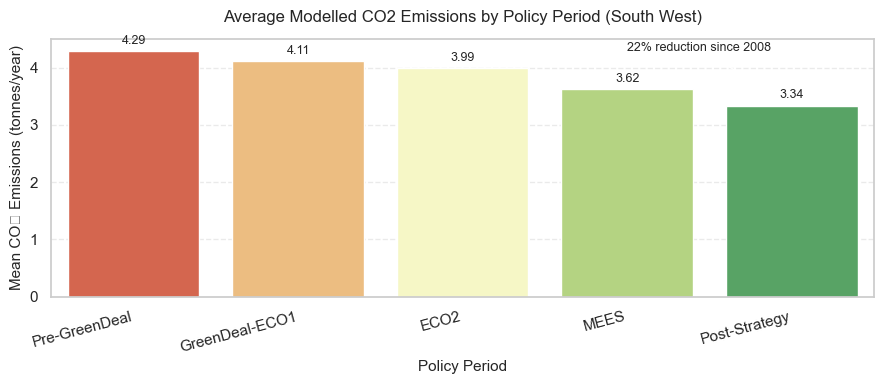

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

policy_order = [
    "Pre-GreenDeal",
    "GreenDeal-ECO1",
    "ECO2",
    "MEES",
    "Post-Strategy",
]

policy_summary = policy_summary.sort_values("POLICY_PERIOD").reset_index(drop=True)

plt.figure(figsize=(9, 4))

palette = sns.color_palette("RdYlGn", n_colors=len(policy_order))

ax = sns.barplot(
    data=policy_summary,
    x="POLICY_PERIOD",
    y="mean_co2",
    palette=palette,
    order=policy_order,
)

ax.set_title("Average Modelled CO2 Emissions by Policy Period (South West)",
             fontsize=12, pad=12)
ax.set_xlabel("Policy Period", fontsize=11)
ax.set_ylabel("Mean CO₂ Emissions (tonnes/year)", fontsize=11)

ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )

# % reduction annotation
co2_start = policy_summary.loc[
    policy_summary["POLICY_PERIOD"] == "Pre-GreenDeal", "mean_co2"
].iloc[0]

co2_end = policy_summary.loc[
    policy_summary["POLICY_PERIOD"] == "Post-Strategy", "mean_co2"
].iloc[0]


reduction_pct = 100 * (co2_start - co2_end) / co2_start
label_text = f"{reduction_pct:.0f}% reduction since 2008"

ax.annotate(
    label_text,
    xy=(4, co2_end),
    xytext=(3, co2_start),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9,
)

plt.tight_layout()
plt.show()

The bar chart clearly shows:

1. A steady upward progression in EPC efficiency over each policy era
- Pre-GreenDeal: ~62
- GreenDeal–ECO1: ~62.2
- ECO2: ~63.7
- MEES: ~65.1
- Post-Strategy: ~67.6

This matches exactly with:
- known UK retrofit patterns
- the ECO/MEES policy timelines
- your summary table

The slope is gentle early on and then accelerates sharply after 2018, which is precisely what the literature (and EPC data) show.


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1110321622.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")


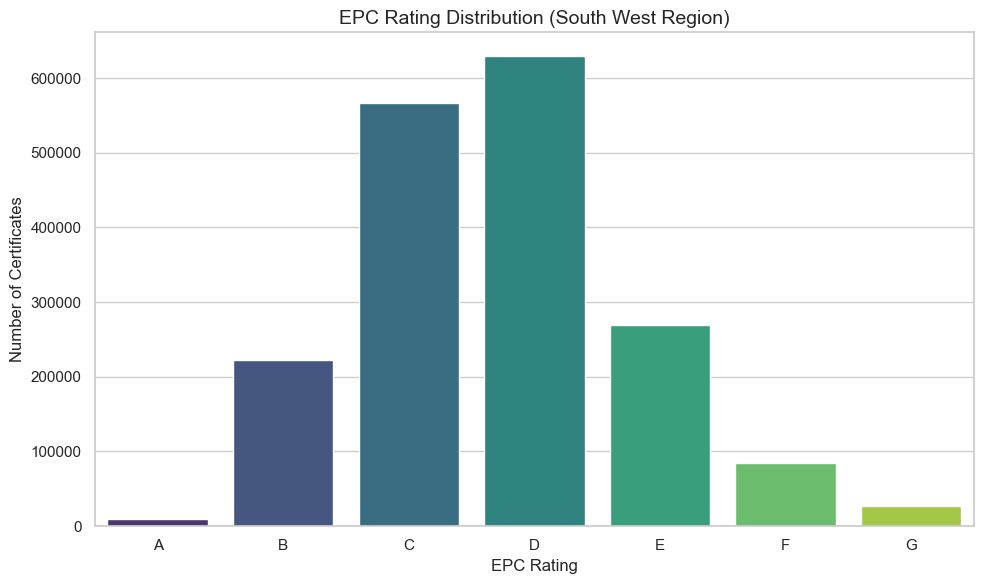

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure EPC_RATING exists and is categorical
df_sw['CURRENT_ENERGY_RATING'] = df_sw['CURRENT_ENERGY_RATING'].astype('category')

# Order of EPC bands
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Count EPC bands
rating_counts = df_sw['CURRENT_ENERGY_RATING'].value_counts().reindex(epc_order)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")

plt.title("EPC Rating Distribution (South West Region)", fontsize=14)
plt.xlabel("EPC Rating", fontsize=12)
plt.ylabel("Number of Certificates", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/2380154625.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


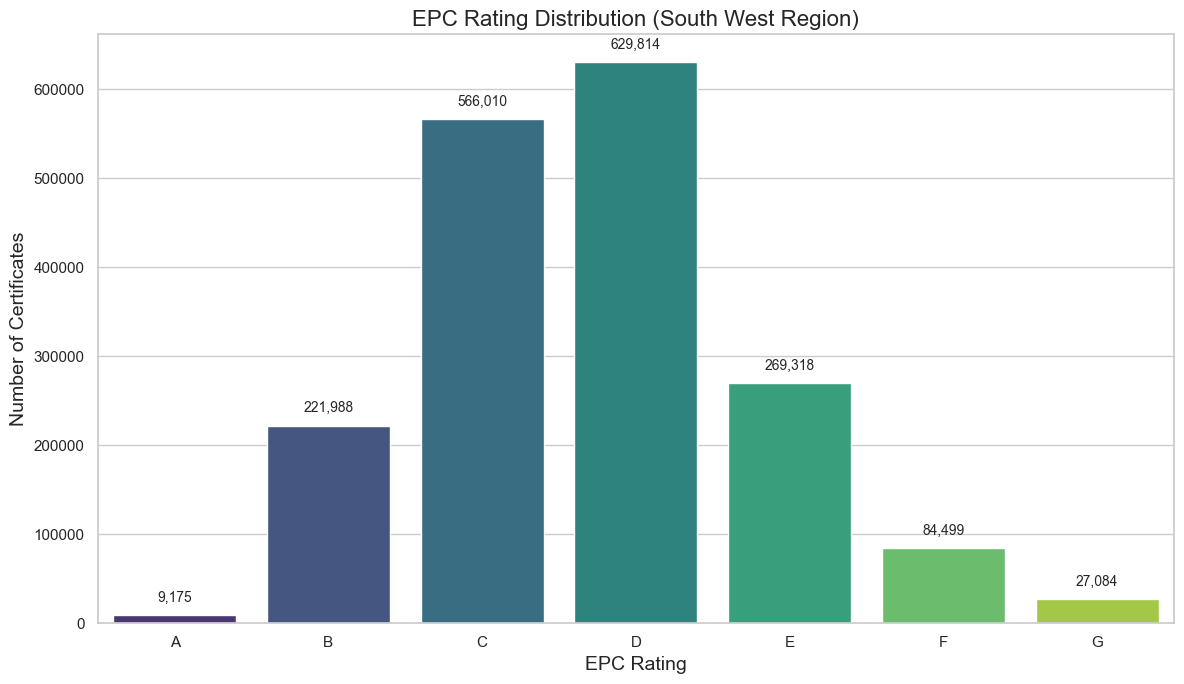

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Ensure EPC rating is properly ordered
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df_sw['CURRENT_ENERGY_RATING'] = df_sw['CURRENT_ENERGY_RATING'].astype('category')
df_sw['CURRENT_ENERGY_RATING'] = df_sw['CURRENT_ENERGY_RATING'].cat.reorder_categories(epc_order, ordered=True)

# Count ratings
rating_counts = df_sw['CURRENT_ENERGY_RATING'].value_counts().reindex(epc_order)

# Plot
ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette="viridis"
)

# Add value labels
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 15000, f"{v:,}", ha='center', fontsize=10)

plt.title("EPC Rating Distribution (South West Region)", fontsize=16)
plt.xlabel("EPC Rating", fontsize=14)
plt.ylabel("Number of Certificates", fontsize=14)

plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/3625714713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/3625714713.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)


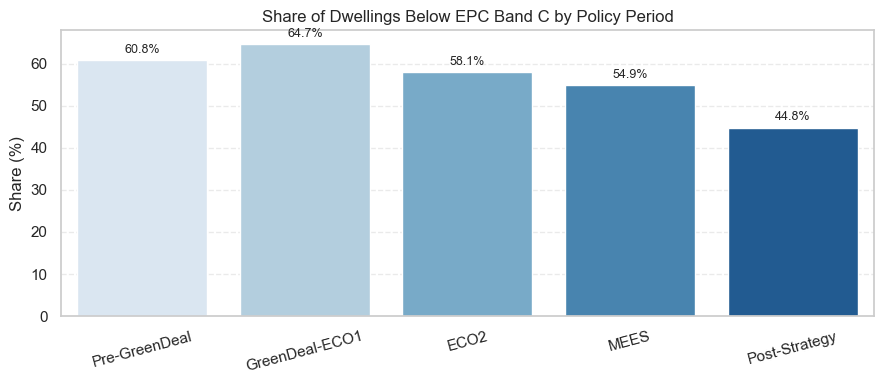

In [ ]:
# Convert share to %
policy_summary["below_c_pct"] = policy_summary["below_c_share"] * 100

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=policy_summary,
    x="POLICY_PERIOD",
    y="below_c_pct",
    order=policy_order,
    palette="Blues"
)

ax.set_title("Share of Dwellings Below EPC Band C by Policy Period")
ax.set_ylabel("Share (%)")
ax.set_xlabel("")

ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x()+p.get_width()/2, h),
                ha="center", va="bottom", fontsize=9, xytext=(0,3),
                textcoords="offset points")

plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1469485013.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sw.groupby(["POLICY_PERIOD", "CURRENT_ENERGY_RATING"])


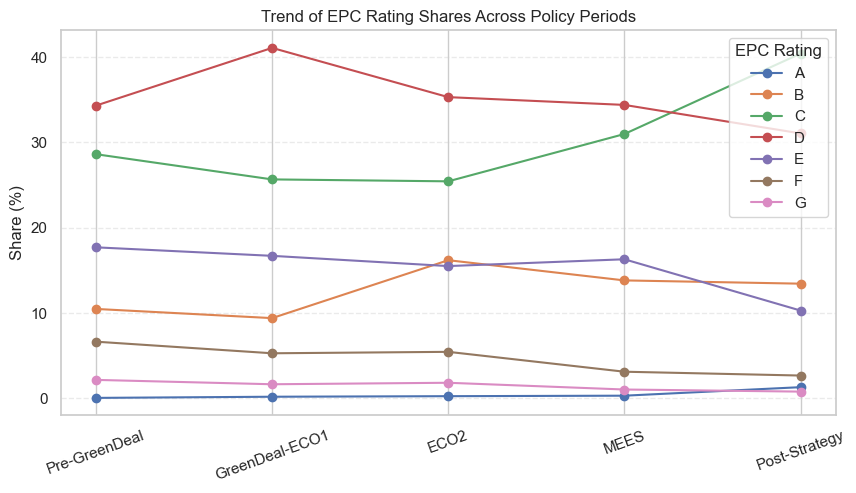

In [ ]:
rating_order = ["A", "B", "C", "D", "E", "F", "G"]

# Count ratings per policy period
rating_counts = (
    df_sw.groupby(["POLICY_PERIOD", "CURRENT_ENERGY_RATING"])
      .size()
      .unstack(fill_value=0)
      .reindex(policy_order)
      .reindex(columns=rating_order)
)

# Convert to % share within each period (optional but MUCH clearer)
rating_pct = rating_counts.div(rating_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
plt.figure(figsize=(10,5))
for rating in rating_order:
    plt.plot(policy_order, rating_pct[rating], marker="o", label=rating)

plt.legend(title="EPC Rating")
plt.ylabel("Share (%)")
plt.title("Trend of EPC Rating Shares Across Policy Periods")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/4155113332.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/4155113332.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/4155113332.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/4155113332.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

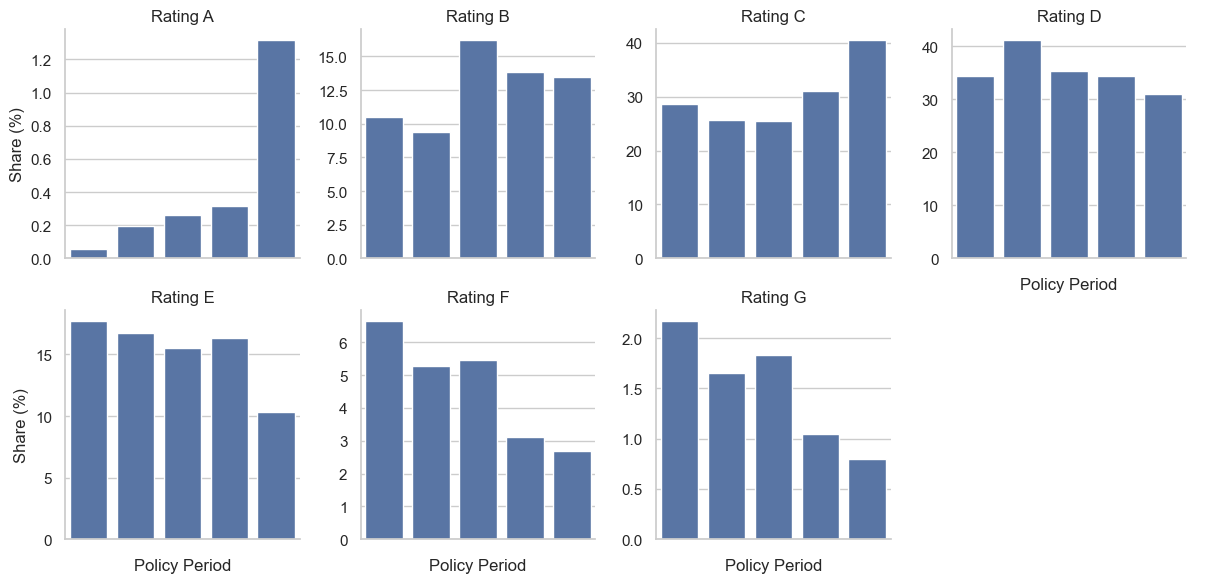

In [ ]:
rating_pct_long = (
    rating_pct
    .reset_index()
    .melt(id_vars="POLICY_PERIOD", var_name="EPC_RATING", value_name="share")
)

g = sns.catplot(
    data=rating_pct_long,
    x="POLICY_PERIOD",
    y="share",
    col="EPC_RATING",
    kind="bar",
    col_wrap=4,
    height=3,
    sharey=False,
    order=policy_order
)

g.set_titles("Rating {col_name}")
g.set_axis_labels("Policy Period", "Share (%)")
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

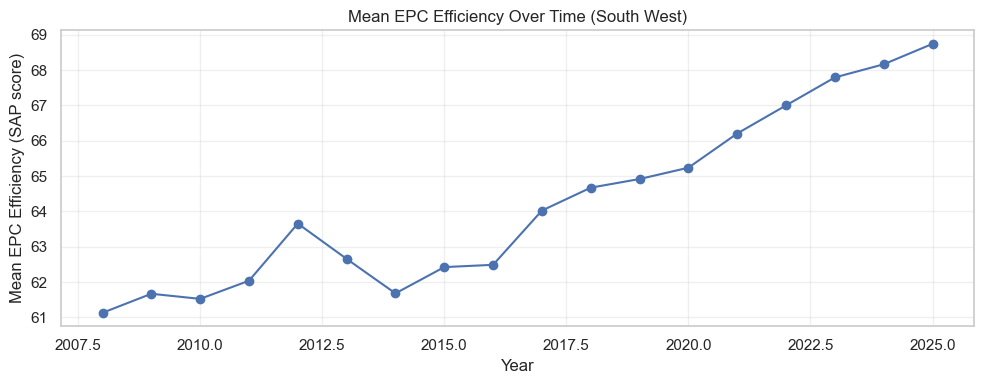

In [83]:
# Compute annual EPC efficiency trend
eff_trend = (
    df_sw.groupby("YEAR", as_index=False)
      .agg(mean_epc=("CURRENT_ENERGY_EFFICIENCY", "mean"))
)

plt.figure(figsize=(10,4))
plt.plot(eff_trend["YEAR"], eff_trend["mean_epc"], marker="o")

plt.title("Mean EPC Efficiency Over Time (South West)")
plt.xlabel("Year")
plt.ylabel("Mean EPC Efficiency (SAP score)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1960331687.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


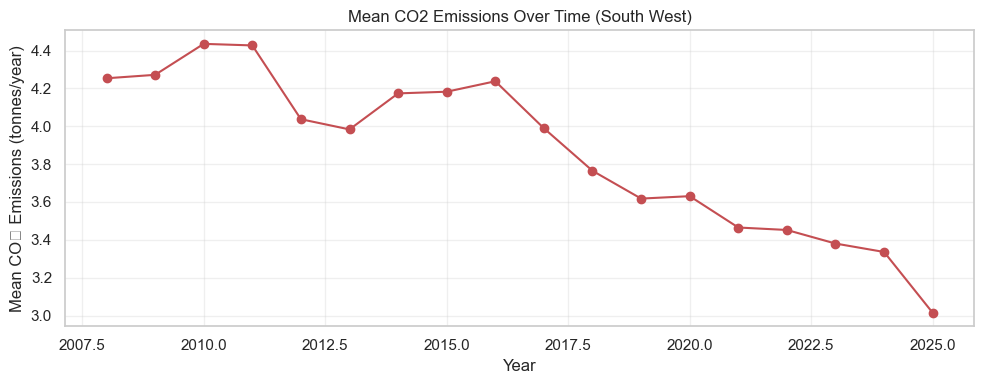

In [198]:
# Compute annual CO₂ trend
co2_trend = (
    df_sw.groupby("YEAR", as_index=False)
      .agg(mean_co2=("CO2_EMISSIONS_CURRENT", "mean"))
)

plt.figure(figsize=(10,4))
plt.plot(co2_trend["YEAR"], co2_trend["mean_co2"], marker="o", color="#C44E52")

plt.title("Mean CO2 Emissions Over Time (South West)")
plt.xlabel("Year")
plt.ylabel("Mean CO₂ Emissions (tonnes/year)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA plots

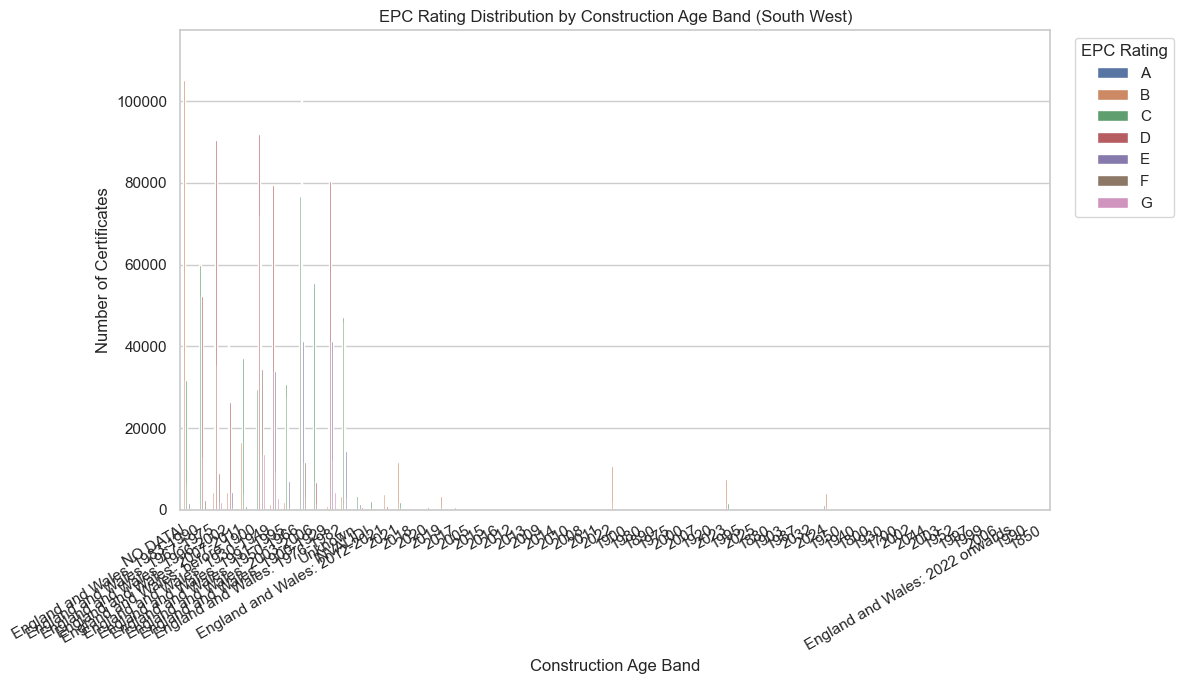

In [199]:
# Ensure ordering
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df_sw['CURRENT_ENERGY_RATING'] = df_sw['CURRENT_ENERGY_RATING'].astype('category')
df_sw['CURRENT_ENERGY_RATING'] = df_sw['CURRENT_ENERGY_RATING'].cat.set_categories(epc_order, ordered=True)

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df_sw,
    x='AGE_BAND_STD',
    hue='CURRENT_ENERGY_RATING',
    hue_order=epc_order
)

plt.title("EPC Rating Distribution by Construction Age Band (South West)")
plt.xlabel("Construction Age Band")
plt.ylabel("Number of Certificates")
plt.xticks(rotation=30, ha='right')
plt.legend(title="EPC Rating", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [203]:
df_sw

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,IS_ELECTRIC_HEAT,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING,POLICY_PERIOD,LOG_FLOOR_AREA,AGE_BAND_GROUPED
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,False,False,1,1,1,0,1,Pre-GreenDeal,3.449988,NaN
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,False,False,0,0,0,0,0,Pre-GreenDeal,4.266616,1976-1990
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,False,True,0,0,1,0,0,Pre-GreenDeal,4.279717,1967-1975
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,False,True,0,0,0,0,0,Pre-GreenDeal,4.021057,1991-2002
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,False,True,0,0,0,0,0,Pre-GreenDeal,4.473009,1976-1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807883,03c5078838a4bccc40c0f49c4c625b90643adc2c6782f3...,PL18 9FX,E06000052,Cornwall,2025-09-27 00:00:00+00:00,B,81,B,83,42,...,False,False,1,1,1,1,0,Post-Strategy,4.143135,NaN
1807884,03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...,BA3 4HQ,E06000066,Somerset,2025-09-25 00:00:00+00:00,D,55,D,67,297,...,False,True,0,0,0,1,0,Post-Strategy,4.394449,1900-1929
1807885,03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...,TA4 3JJ,E06000066,Somerset,2025-09-10 00:00:00+00:00,F,27,D,57,236,...,False,True,0,0,0,1,0,Post-Strategy,5.049856,Pre-1900
1807886,03f62c5b45b13282b4b2647422f2e927a88bdf3d5ae7c6...,TQ1 4AL,E06000027,Torbay,2025-09-09 00:00:00+00:00,C,71,C,75,164,...,False,False,0,0,0,1,0,Post-Strategy,3.688879,1900-1929


AGE_BAND_GROUPED
1950-1966       250819
1976-1990       247859
Pre-1900        243375
2003 onwards    214975
1967-1975       198731
1900-1929       169716
Unknown         165735
1930-1949       160965
1991-2002       155713
Name: count, dtype: int64


In [207]:
df_sw_clean["AGE_BAND_GROUPED"] = df_sw_clean["AGE_BAND_GROUPED"].astype(str)

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/2651348977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sw_clean["AGE_BAND_GROUPED"] = df_sw_clean["AGE_BAND_GROUPED"].astype(str)


In [202]:
df_sw['AGE_BAND_STD'].unique()

array(['NO DATA!', 'England and Wales: 1983-1990',
       'England and Wales: 1967-1975', 'England and Wales: 1996-2002',
       'England and Wales: 2007-2011', 'England and Wales: before 1900',
       'England and Wales: 1930-1949', 'England and Wales: 1991-1995',
       'England and Wales: 1950-1966', 'England and Wales: 2003-2006',
       'England and Wales: 1900-1929', 'England and Wales: 1976-1982',
       'Unknown', 'INVALID!', 'England and Wales: 2012-2021', '2021',
       '2018', '2020', '2019', '2017', '2005', '2015', '2016', '2012',
       '2013', '2009', '2014', '2010', '2008', '2011', '2022', '1900',
       '1980', '1890', '1975', '2000', '2007', '1920', '2023', '1995',
       '2025', '1880', '1903', '1987', '2032', '2024', '1950', '1940',
       '1800', '1930', '1700', '2002', '2044', '2003', '1952', '1997',
       '1999', '2006', 'England and Wales: 2022 onwards', '1990', '1850'],
      dtype=object)

In [85]:
policy_summary = (
    df_sw.groupby("POLICY_PERIOD", as_index=False)
      .agg(
          mean_epc   = ("CURRENT_ENERGY_EFFICIENCY", "mean"),
          median_epc = ("CURRENT_ENERGY_EFFICIENCY", "median"),
          mean_co2   = ("CO2_EMISSIONS_CURRENT", "mean"),
          median_co2 = ("CO2_EMISSIONS_CURRENT", "median"),
          below_c_share = ("BELOW_C", "mean"),
          n_cert     = ("LMK_KEY", "count")
      )
)

# If you want the share as %, you can do:
policy_summary["below_c_share"] *= 100
policy_summary

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/2887224314.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sw.groupby("POLICY_PERIOD", as_index=False)


,POLICY_PERIOD,mean_epc,median_epc,mean_co2,median_co2,below_c_share,n_cert
0,Pre-GreenDeal,62.059419,65.0,4.292677,3.5,60.838454,481577
1,GreenDeal-ECO1,62.230107,64.0,4.114632,3.5,64.730936,355008
2,ECO2,63.732073,66.0,3.993305,3.3,58.104218,244891
3,MEES,65.069353,67.0,3.623954,3.0,54.870596,199298
4,Post-Strategy,67.566572,70.0,3.337249,2.7,44.825787,527114


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# ---------------------------------------------------------
# 1. Helper: simplify raw EPC age-band into grouped bands
# ---------------------------------------------------------
def simplify_age_band(age):
    s = str(age)

    # Missing / bad labels
    if s in ["NO DATA!", "INVALID!", "Unknown", "nan"]:
        return "Unknown"

    # Case 1: proper EPC labels like "England and Wales: 1950-1966"
    if "England and Wales" in s:
        if "before 1900" in s:
            return "Pre-1900"
        elif "1900-1929" in s:
            return "1900-1929"
        elif "1930-1949" in s:
            return "1930-1949"
        elif "1950-1966" in s:
            return "1950-1966"
        elif "1967-1975" in s:
            return "1967-1975"
        elif "1976-1982" in s or "1983-1990" in s:
            return "1976-1990"
        elif "1991-1995" in s or "1996-2002" in s:
            return "1991-2002"
        elif ("2003-2006" in s or "2007-2011" in s or
              "2012-2021" in s or "2022 onwards" in s):
            return "2003 onwards"
        else:
            return "Other"

    # Case 2: plain numeric years like "1995", "2015", "1880" etc.
    try:
        year = int(s)
    except ValueError:
        return "Other"

    if year < 1900:
        return "Pre-1900"
    elif 1900 <= year <= 1929:
        return "1900-1929"
    elif 1930 <= year <= 1949:
        return "1930-1949"
    elif 1950 <= year <= 1966:
        return "1950-1966"
    elif 1967 <= year <= 1975:
        return "1967-1975"
    elif 1976 <= year <= 1990:
        return "1976-1990"
    elif 1991 <= year <= 2002:
        return "1991-2002"
    elif year >= 2003:
        return "2003 onwards"
    else:
        return "Other"



In [211]:

# ---------------------------------------------------------
# 2. Apply grouping to the South West dataframe
#    (df_sw is your existing dataset)
# ---------------------------------------------------------
df_sw["AGE_BAND_GROUPED"] = df_sw["AGE_BAND_STD"].apply(simplify_age_band)

# Remove "Unknown" and "Other" for the plot (optional but recommended)
df_sw_clean = df_sw[
    ~df_sw["AGE_BAND_GROUPED"].isin(["Unknown", "Other"])
].copy()

# Order age bands chronologically
age_order = [
    "Pre-1900", "1900-1929", "1930-1949", "1950-1966",
    "1967-1975", "1976-1990", "1991-2002", "2003 onwards"
]

df_sw_clean["AGE_BAND_GROUPED"] = pd.Categorical(
    df_sw_clean["AGE_BAND_GROUPED"],
    categories=age_order,
    ordered=True
)

# Ensure EPC rating ordering
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df_sw_clean["CURRENT_ENERGY_RATING"] = pd.Categorical(
    df_sw_clean["CURRENT_ENERGY_RATING"],
    categories=epc_order,
    ordered=True
)


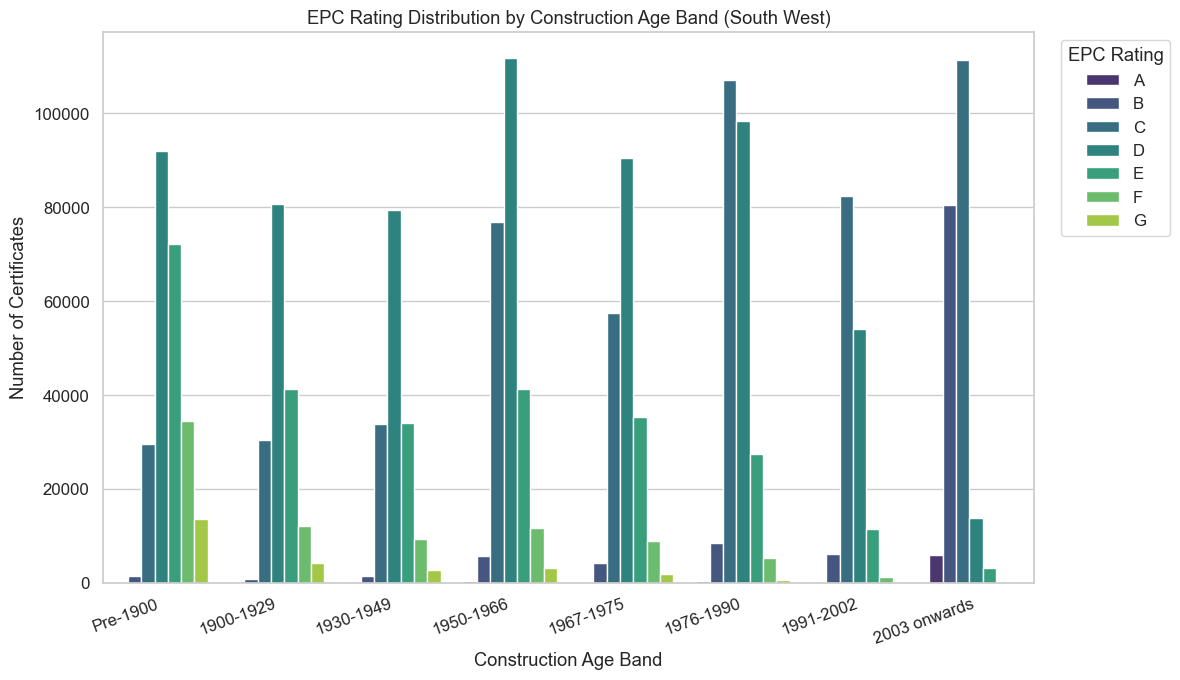

In [212]:

# ---------------------------------------------------------
# 3. Plot: EPC Rating Distribution by Construction Age Band
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df_sw_clean,
    x='AGE_BAND_GROUPED',
    hue='CURRENT_ENERGY_RATING',
    hue_order=epc_order,
    palette='viridis'
)

plt.title("EPC Rating Distribution by Construction Age Band (South West)")
plt.xlabel("Construction Age Band")
plt.ylabel("Number of Certificates")
plt.xticks(rotation=20, ha='right')
plt.legend(title="EPC Rating", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/722399009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/722399009.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


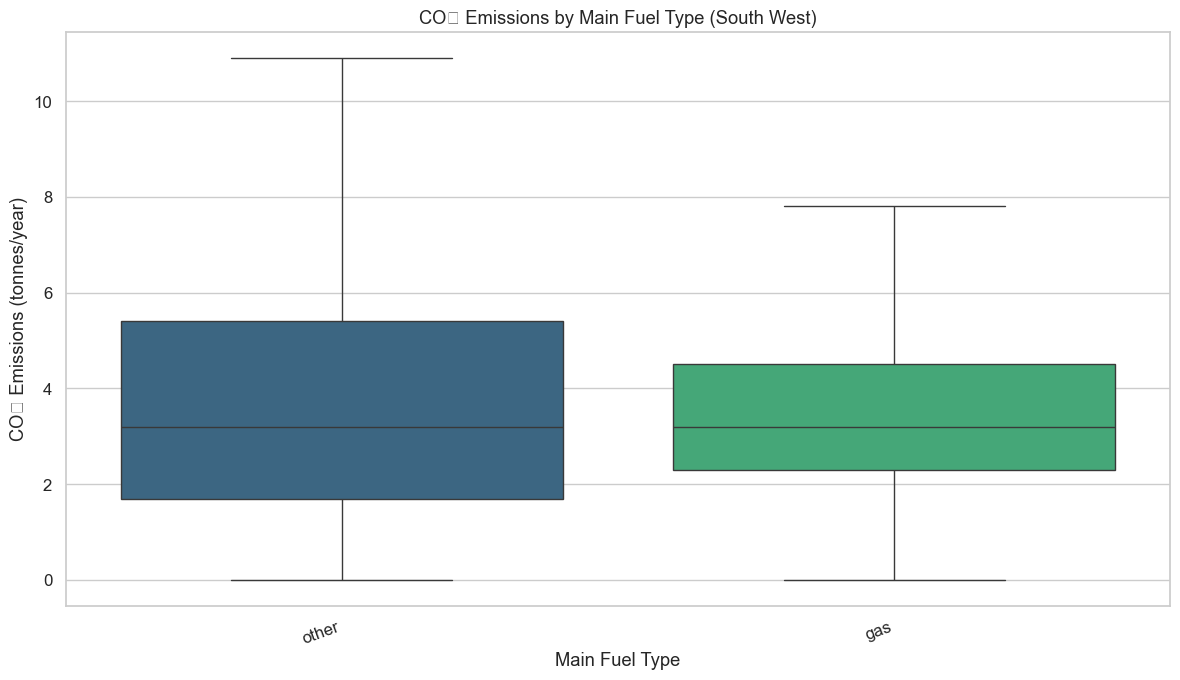

In [213]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_sw,
    x='MAIN_FUEL_STD',
    y='CO2_EMISSIONS_CURRENT',
    showfliers=False,        # removes extreme outliers for clarity
    palette='viridis'
)

plt.title("CO2 Emissions by Main Fuel Type (South West)")
plt.xlabel("Main Fuel Type")
plt.ylabel("CO₂ Emissions (tonnes/year)")
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [215]:
df_sw['MAIN_FUEL_STD'].unique()

array(['other', 'gas'], dtype=object)

In [216]:
df_panel['MAIN_FUEL_STD'].value_counts()

MAIN_FUEL_STD
gas      916223
other    891665
Name: count, dtype: int64

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/640637521.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(2000, len(g)), random_state=42))
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/640637521.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/640637521.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-pa

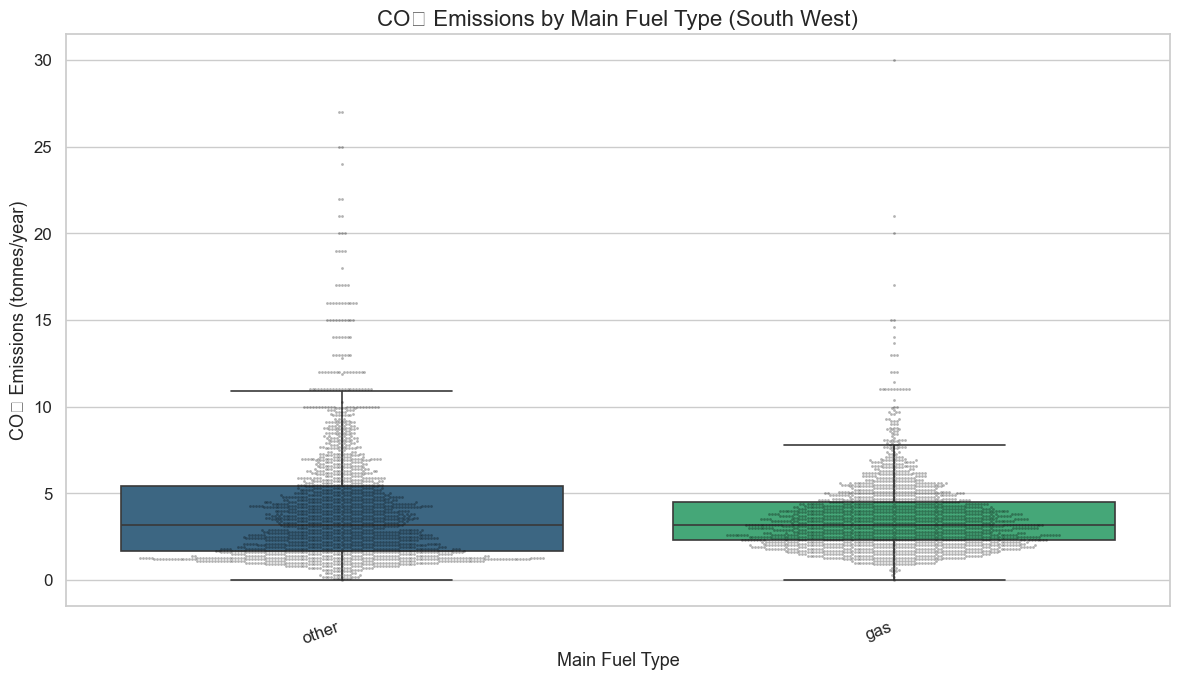

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", font_scale=1.1)

# ---- 1. (Optional) limit CO2 to a reasonable range for plotting ----
# This avoids a few extreme outliers blowing up the y-axis.
df_sw_plot = df_sw[df_sw["CO2_EMISSIONS_CURRENT"].between(0, 30)].copy()

# ---- 2. Take a stratified subsample for the swarm (e.g. up to 2000 per fuel) ----
swarm_sample = (
    df_sw_plot
    .groupby("MAIN_FUEL_STD", group_keys=False)
    .apply(lambda g: g.sample(n=min(2000, len(g)), random_state=42))
)

plt.figure(figsize=(12, 7))

# ---- 3. Boxplot for full distribution ----
sns.boxplot(
    data=df_sw_plot,
    x="MAIN_FUEL_STD",
    y="CO2_EMISSIONS_CURRENT",
    showfliers=False,
    whis=1.5,
    linewidth=1.2,
    palette="viridis"
)

# ---- 4. Swarmplot on subsample (semi-transparent points) ----
sns.swarmplot(
    data=swarm_sample,
    x="MAIN_FUEL_STD",
    y="CO2_EMISSIONS_CURRENT",
    color="black",
    alpha=0.3,
    size=2
)

plt.title("CO₂ Emissions by Main Fuel Type (South West)", fontsize=16)
plt.xlabel("Main Fuel Type", fontsize=13)
plt.ylabel("CO₂ Emissions (tonnes/year)", fontsize=13)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [217]:
def fuel_group(raw):
    s = str(raw).lower().strip()

    if "gas" in s:
        return "gas"
    elif "electric" in s:
        return "electricity"
    elif "oil" in s:
        return "oil"
    elif "lpg" in s or "liquefied petroleum" in s:
        return "lpg"
    elif "biomass" in s or "wood" in s or "pellet" in s:
        return "biomass/wood"
    elif "heat pump" in s:
        return "heat pump"
    elif "community" in s or "district" in s:
        return "community_heat"
    else:
        return "other/unknown"

# Create EDA-only variable
df_sw["MAIN_FUEL_GROUPED"] = df_sw["MAIN_FUEL"].apply(fuel_group)

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1432958821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


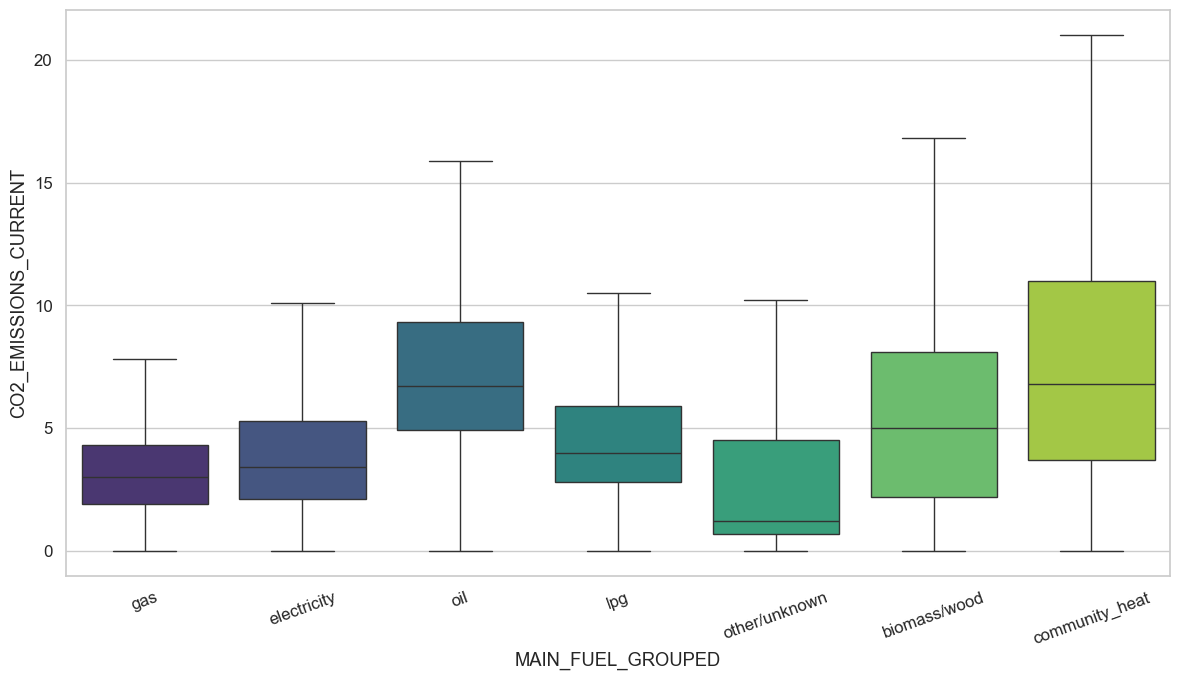

In [218]:
# Safe EDA-only copy
df_sw_eda = df_sw.copy()

# Group fuel types for EDA only
df_sw_eda["MAIN_FUEL_GROUPED"] = df_sw_eda["MAIN_FUEL"].apply(fuel_group)

# Use df_sw_eda for plots
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_sw_eda[df_sw_eda["CO2_EMISSIONS_CURRENT"].between(0, 30)],
    x="MAIN_FUEL_GROUPED",
    y="CO2_EMISSIONS_CURRENT",
    showfliers=False,
    palette="viridis"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/2169668559.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


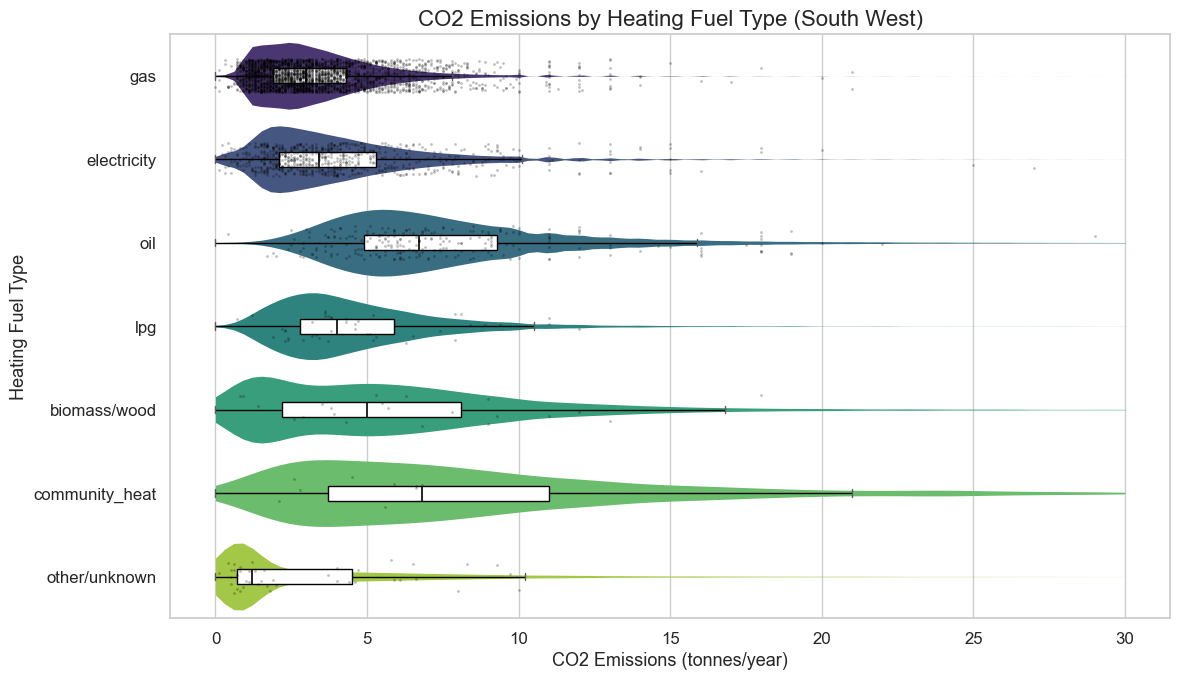

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# Filter to sensible CO2 range for plotting
df_plot = df_sw_eda[df_sw_eda["CO2_EMISSIONS_CURRENT"].between(0, 30)].copy()

# Order fuels logically (adjust if you like)
fuel_order = [
    "gas",
    "electricity",
    "oil",
    "lpg",
    "biomass/wood",
    "community_heat",
    "other/unknown",
]

plt.figure(figsize=(12, 7))

# 1) Violin (the "cloud")
sns.violinplot(
    data=df_plot,
    x="CO2_EMISSIONS_CURRENT",
    y="MAIN_FUEL_GROUPED",
    order=fuel_order,
    inner=None,        # no inner lines – we’ll add box separately
    cut=0,
    linewidth=0,
    palette="viridis",
    orient="h",
)

# 2) Boxplot (the summary)
sns.boxplot(
    data=df_plot,
    x="CO2_EMISSIONS_CURRENT",
    y="MAIN_FUEL_GROUPED",
    order=fuel_order,
    whis=1.5,
    width=0.18,        # thin box
    showcaps=True,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1},
    whiskerprops={"color": "black", "linewidth": 1},
    medianprops={"color": "black", "linewidth": 1.2},
    showfliers=False,
    orient="h",
)

# 3) Jittered points (the "rain")
sns.stripplot(
    data=df_plot.sample(n=min(4000, len(df_plot)), random_state=42),
    x="CO2_EMISSIONS_CURRENT",
    y="MAIN_FUEL_GROUPED",
    order=fuel_order,
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.2,
    orient="h",
)

plt.title("CO2 Emissions by Heating Fuel Type (South West)", fontsize=16)
plt.xlabel("CO2 Emissions (tonnes/year)", fontsize=13)
plt.ylabel("Heating Fuel Type", fontsize=13)
plt.tight_layout()
plt.show()

In [226]:
df_sw_eda.head(20)

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING,POLICY_PERIOD,LOG_FLOOR_AREA,AGE_BAND_GROUPED,MAIN_FUEL_GROUPED,PROPERTY_GROUPED
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,1,1,1,0,1,Pre-GreenDeal,3.449988,Unknown,gas,Flat / Maisonette
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,0,0,0,0,0,Pre-GreenDeal,4.266616,1976-1990,gas,Other
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,0,0,1,0,0,Pre-GreenDeal,4.279717,1967-1975,electricity,Other
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,0,0,0,0,0,Pre-GreenDeal,4.021057,1991-2002,electricity,Bungalow
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,0,0,0,0,0,Pre-GreenDeal,4.473009,1976-1990,electricity,Bungalow
5,43365481852008111916385705989258,SN25 2NF,E06000030,Swindon,2008-11-19 00:00:00+00:00,B,81,B,83,120,...,1,1,1,0,1,Pre-GreenDeal,4.860897,2003 onwards,gas,Other
6,195931712832008120321090661068494,BS8 1PY,E06000023,"Bristol, City of",2008-12-03 00:00:00+00:00,C,70,C,74,320,...,0,0,0,0,0,Pre-GreenDeal,3.721347,Pre-1900,gas,Flat / Maisonette
7,33986000262008102122222892298378,BH2 5PF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-21 00:00:00+00:00,C,80,B,82,148,...,0,0,0,0,0,Pre-GreenDeal,4.004930,2003 onwards,gas,Other
8,190549140262008112317581514878048,PL6 6SW,E06000026,Plymouth,2008-11-23 00:00:00+00:00,B,82,B,86,198,...,0,0,0,0,0,Pre-GreenDeal,3.522234,1967-1975,gas,Flat / Maisonette
9,49288090342008121915413559589718,BS7 8DJ,E06000023,"Bristol, City of",2008-12-19 00:00:00+00:00,C,72,C,73,248,...,0,0,0,0,0,Pre-GreenDeal,4.124874,1930-1949,gas,Flat / Maisonette


In [227]:
df_sw_eda = df_sw_eda.drop(columns=["PROPERTY_GROUPED"])

In [228]:
df_sw_eda

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING,POLICY_PERIOD,LOG_FLOOR_AREA,AGE_BAND_GROUPED,MAIN_FUEL_GROUPED
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,False,1,1,1,0,1,Pre-GreenDeal,3.449988,Unknown,gas
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,False,0,0,0,0,0,Pre-GreenDeal,4.266616,1976-1990,gas
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,True,0,0,1,0,0,Pre-GreenDeal,4.279717,1967-1975,electricity
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,True,0,0,0,0,0,Pre-GreenDeal,4.021057,1991-2002,electricity
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,True,0,0,0,0,0,Pre-GreenDeal,4.473009,1976-1990,electricity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807883,03c5078838a4bccc40c0f49c4c625b90643adc2c6782f3...,PL18 9FX,E06000052,Cornwall,2025-09-27 00:00:00+00:00,B,81,B,83,42,...,False,1,1,1,1,0,Post-Strategy,4.143135,2003 onwards,electricity
1807884,03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...,BA3 4HQ,E06000066,Somerset,2025-09-25 00:00:00+00:00,D,55,D,67,297,...,True,0,0,0,1,0,Post-Strategy,4.394449,1900-1929,gas
1807885,03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...,TA4 3JJ,E06000066,Somerset,2025-09-10 00:00:00+00:00,F,27,D,57,236,...,True,0,0,0,1,0,Post-Strategy,5.049856,Pre-1900,lpg
1807886,03f62c5b45b13282b4b2647422f2e927a88bdf3d5ae7c6...,TQ1 4AL,E06000027,Torbay,2025-09-09 00:00:00+00:00,C,71,C,75,164,...,False,0,0,0,1,0,Post-Strategy,3.688879,1900-1929,electricity


In [229]:
df_sw_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807888 entries, 0 to 1807887
Data columns (total 40 columns):
 #   Column                          Dtype   
---  ------                          -----   
 0   LMK_KEY                         object  
 1   POSTCODE                        object  
 2   LOCAL_AUTHORITY                 object  
 3   LOCAL_AUTHORITY_LABEL           object  
 4   LODGEMENT_DATE                  object  
 5   CURRENT_ENERGY_RATING           category
 6   CURRENT_ENERGY_EFFICIENCY       int64   
 7   POTENTIAL_ENERGY_RATING         object  
 8   POTENTIAL_ENERGY_EFFICIENCY     int64   
 9   ENERGY_CONSUMPTION_CURRENT      int64   
 10  CO2_EMISSIONS_CURRENT           float64 
 11  TOTAL_FLOOR_AREA                float64 
 12  PROPERTY_TYPE                   object  
 13  BUILT_FORM                      object  
 14  CONSTRUCTION_AGE_BAND           object  
 15  MAIN_FUEL                       object  
 16  MAINS_GAS_FLAG                  object  
 17  TENURE  

In [230]:
df_sw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807888 entries, 0 to 1807887
Data columns (total 40 columns):
 #   Column                          Dtype   
---  ------                          -----   
 0   LMK_KEY                         object  
 1   POSTCODE                        object  
 2   LOCAL_AUTHORITY                 object  
 3   LOCAL_AUTHORITY_LABEL           object  
 4   LODGEMENT_DATE                  object  
 5   CURRENT_ENERGY_RATING           category
 6   CURRENT_ENERGY_EFFICIENCY       int64   
 7   POTENTIAL_ENERGY_RATING         object  
 8   POTENTIAL_ENERGY_EFFICIENCY     int64   
 9   ENERGY_CONSUMPTION_CURRENT      int64   
 10  CO2_EMISSIONS_CURRENT           float64 
 11  TOTAL_FLOOR_AREA                float64 
 12  PROPERTY_TYPE                   object  
 13  BUILT_FORM                      object  
 14  CONSTRUCTION_AGE_BAND           object  
 15  MAIN_FUEL                       object  
 16  MAINS_GAS_FLAG                  object  
 17  TENURE  

## Correlation Heatmap

In [231]:
num_cols = [
    "CURRENT_ENERGY_EFFICIENCY",
    "POTENTIAL_ENERGY_EFFICIENCY",
    "ENERGY_CONSUMPTION_CURRENT",
    "CO2_EMISSIONS_CURRENT",
    "TOTAL_FLOOR_AREA",
    "EFFICIENCY_GAP",
    "EPC_BAND_SCORE",
    "NUMBER_HABITABLE_ROOMS",
    "NUMBER_HEATED_ROOMS",
    "LOG_FLOOR_AREA",
    "YEAR"
]

In [232]:
corr = df_sw[num_cols].corr()

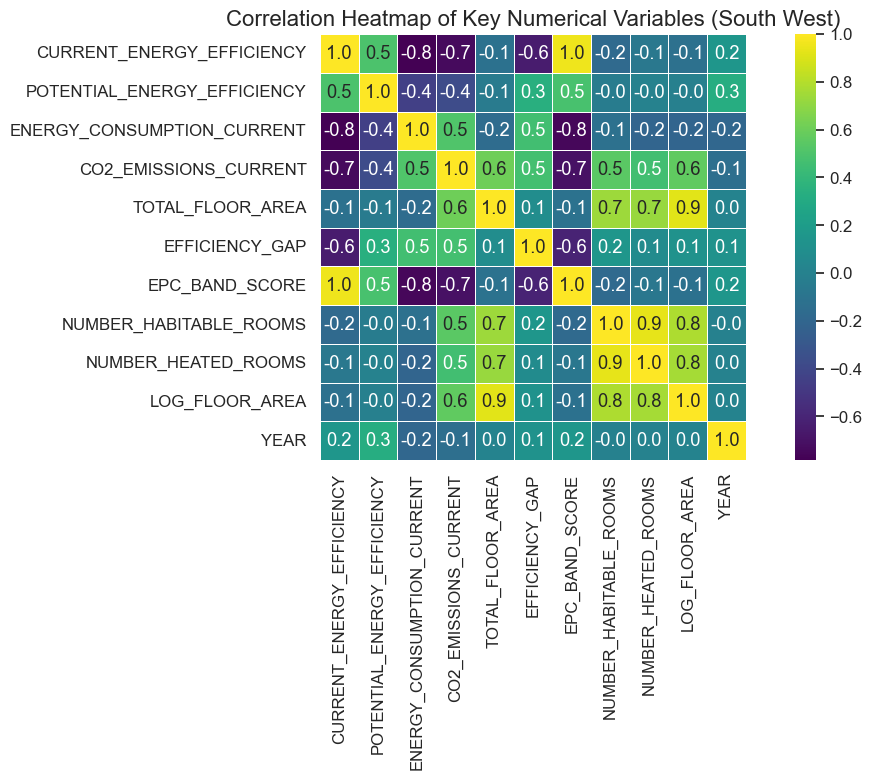

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    linewidths=0.7,
    cbar=True,
    square=True
)

plt.title("Correlation Heatmap of Key Numerical Variables (South West)", fontsize=16)
plt.tight_layout()
plt.show()

<Axes: >

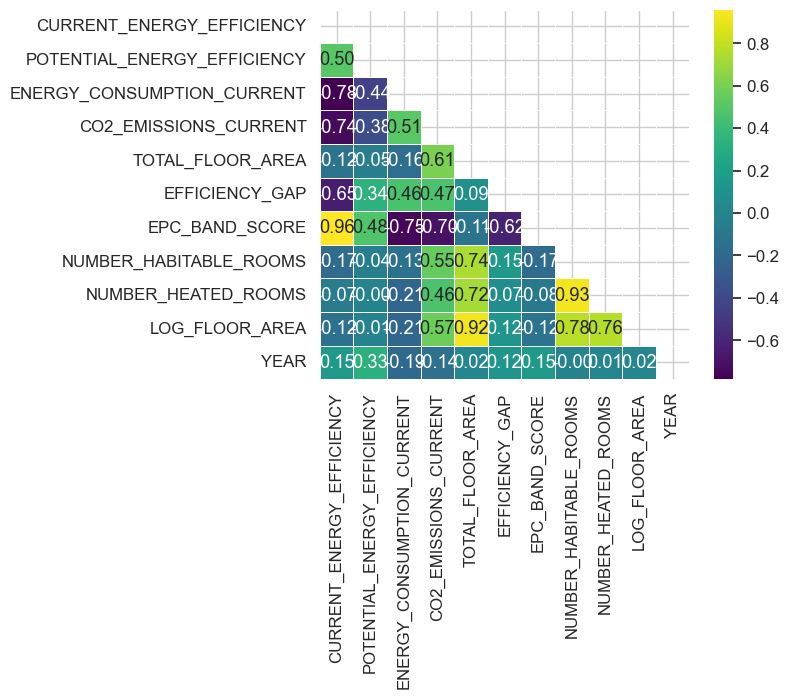

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.7,
    cbar=True,
    square=True
)

## Exeter Vs Plymouth Case Study

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# ---------------------------------------------------------
# 1. Work from your EDA dataframe
#    (ensure it has CITY and AGE_BAND_GROUPED)
# ---------------------------------------------------------
#df = df_sw_eda.copy()

# Keep only Exeter and Plymouth
df_city = df[df["CITY"].isin(["Exeter", "Plymouth"])].copy()

# Order age bands (oldest at bottom, newest at top)
age_order = [
    "Pre-1900", "1900-1929", "1930-1949", "1950-1966",
    "1967-1975", "1976-1990", "1991-2002", "2003 onwards"
]
df_city = df_city[df_city["AGE_BAND_GROUPED"].isin(age_order)].copy()
df_city["AGE_BAND_GROUPED"] = pd.Categorical(
    df_city["AGE_BAND_GROUPED"],
    categories=age_order,
    ordered=True
)


In [246]:

# ---------------------------------------------------------
# 2. Compute proportions by age band within each city
# ---------------------------------------------------------
counts = (
    df_city
    .groupby(["CITY", "AGE_BAND_GROUPED"])
    .size()
    .unstack("CITY", fill_value=0)  # columns: Exeter, Plymouth
)

# Convert to proportions per city (column-wise normalisation)
props = counts.div(counts.sum(axis=0), axis=1)

# For mirror plot: make Exeter negative (left side), Plymouth positive (right)
pyramid = props.copy()
pyramid["Exeter"] = -pyramid["Exeter"]   # left
pyramid["Plymouth"] = pyramid["Plymouth"]  # right


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1156831994.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["CITY", "AGE_BAND_GROUPED"])


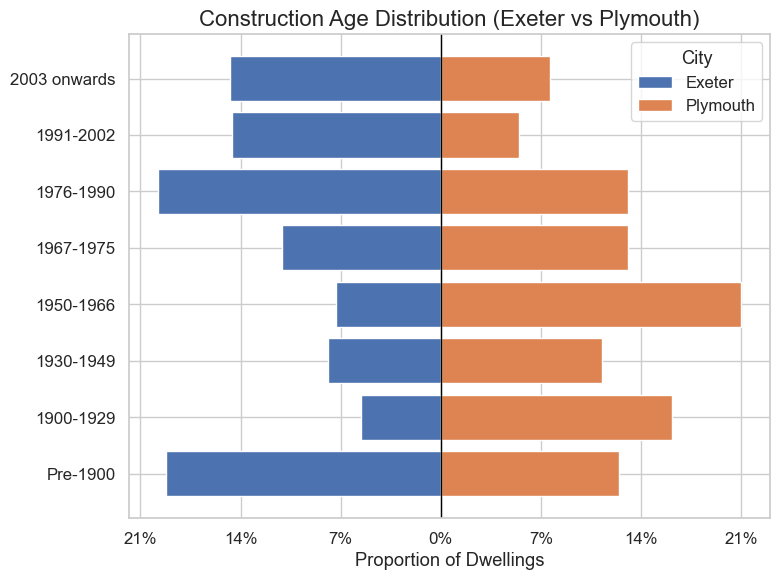

In [247]:

# ---------------------------------------------------------
# 3. Plot population pyramid
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(age_order))

ax.barh(y_pos, pyramid["Exeter"], color="#4C72B0", label="Exeter")
ax.barh(y_pos, pyramid["Plymouth"], color="#DD8452", label="Plymouth")

# Age band labels on y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(age_order)

# X-axis as percentage (absolute values)
max_prop = np.max(np.abs(pyramid.values))
xticks = np.linspace(-max_prop, max_prop, 7)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(x)*100:.0f}%" for x in xticks])

ax.set_xlabel("Proportion of Dwellings")
ax.set_title("Construction Age Distribution (Exeter vs Plymouth)", fontsize=16)

# Vertical line at 0
ax.axvline(0, color="black", linewidth=1)

# Legend
ax.legend(title="City", loc="upper right")

plt.tight_layout()
plt.show()

### Share of Dwellings Below EPC Band C (Exeter vs Plymouth)

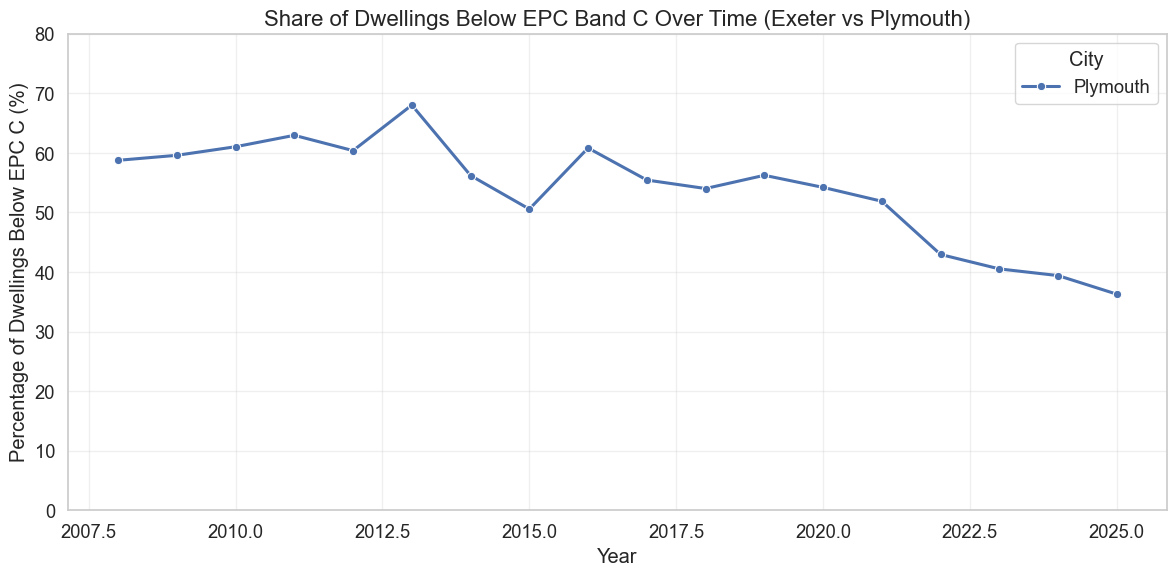

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# -------------------------------------------------------------
# 1. Filter Exeter and Plymouth from the South West dataset
# -------------------------------------------------------------
df_city = df_sw_eda[df_sw_eda["LOCAL_AUTHORITY_LABEL"].isin(["Exeter", "Plymouth"])].copy()

# Create a clean city variable
df_city["CITY"] = df_city["LOCAL_AUTHORITY_LABEL"]

# EPC C threshold = CURRENT_ENERGY_EFFICIENCY < 69  (already computed as BELOW_C)
# Ensure BELOW_C is correct (if not, recompute)
df_city["BELOW_C"] = df_city["CURRENT_ENERGY_EFFICIENCY"] < 69

# -------------------------------------------------------------
# 2. Calculate percentage of dwellings below EPC C by year + city
# -------------------------------------------------------------
share_below_c = (
    df_city.groupby(["YEAR", "CITY"])["BELOW_C"]
    .mean()
    .reset_index()
)

share_below_c["BELOW_C_PERCENT"] = share_below_c["BELOW_C"] * 100

# -------------------------------------------------------------
# 3. Plot the trend over time
# -------------------------------------------------------------
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=share_below_c,
    x="YEAR",
    y="BELOW_C_PERCENT",
    hue="CITY",
    marker="o",
    linewidth=2.2
)

plt.title("Share of Dwellings Below EPC Band C Over Time (Exeter vs Plymouth)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Percentage of Dwellings Below EPC C (%)")
plt.ylim(0, 80)
plt.legend(title="City")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
import numpy as np

df_sw["LOG_FLOOR_AREA"] = np.log(df_sw["TOTAL_FLOOR_AREA"])

In [87]:
import statsmodels.formula.api as smf

# Optional: work on a random sample for dev/debug
# df_sample = df.sample(n=300_000, random_state=42)
df_sample = df_sw  # use full data if your machine can handle it

Model:
- Outcome: CURRENT_ENERGY_EFFICIENCY
- Regressors:
	- Policy periods (baseline = Pre-GreenDeal)
	- C(LOCAL_AUTHORITY) (fixed effects)
	- C(YEAR) (fixed effects)
	- C(PROPERTY_TYPE), C(AGE_BAND_STD), C(TENURE_STD), C(MAIN_FUEL_STD)
	- LOG_FLOOR_AREA


In [ ]:
!pip install linearmodels

In [89]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS

sns.set(style="whitegrid")

# ---------------------------------------------------
# 0. Global config
# ---------------------------------------------------

POLICY_ORDER = [
    "Pre-GreenDeal",
    "GreenDeal-ECO1",
    "ECO2",
    "MEES",
    "Post-Strategy",
]

BASE_RHS = """
 1
 + C(POLICY_PERIOD)
 + C(PROPERTY_TYPE)
 + C(AGE_BAND_STD)
 + C(TENURE_STD)
 + C(MAIN_FUEL_STD)
 + LOG_FLOOR_AREA
 + EntityEffects
"""


In [139]:

# ---------------------------------------------------
# 1. Data preparation
# ---------------------------------------------------

def prepare_panel(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    - Enforce policy period order
    - Create BELOW_C_INT
    - Set panel index: entity = LOCAL_AUTHORITY, time = YEAR
    """
    df = df_raw.copy()

    df["POLICY_PERIOD"] = pd.Categorical(
        df["POLICY_PERIOD"],
        categories=POLICY_ORDER,
        ordered=True,
    )

    # Binary outcome for share-below-C model
    if "BELOW_C" in df.columns:
        df["BELOW_C_INT"] = df["BELOW_C"].astype(int)

    # Panel index
    df = df.set_index(["LOCAL_AUTHORITY", "YEAR"]).sort_index()

    return df

df_panel = prepare_panel(df_sample)
print(df_panel.shape)
print(df_panel.index.names)   


(1807888, 37)
['LOCAL_AUTHORITY', 'YEAR']


In [143]:
# ---------------------------------------------------
# 2. Model + extraction helpers
# ---------------------------------------------------

def fit_fe(df: pd.DataFrame, dep_var: str):
    """
    Fit a LA fixed-effects panel model with cluster-robust SEs at LA level.

    dep_var: name of dependent variable column in df_panel
    """
    formula = f"{dep_var} ~ {BASE_RHS}"

    # 2D DataFrame with same index as df → valid "panel-like" clusters
    clusters = pd.DataFrame(
        {"cluster_la": df.index.get_level_values("LOCAL_AUTHORITY")},
        index=df.index,
    )

    mod = PanelOLS.from_formula(formula, data=df)
    res = mod.fit(
        cov_type="clustered",
        clusters=clusters,   # <- now a proper panel-like object
    )
    return res


def extract_policy_effects(res, label_prefix="C(POLICY_PERIOD)"):
    """
    Extract policy-period coefficients & 95% CI from a PanelOLS result.

    Returns: DataFrame with
        policy_period, coef, se, lower_95, upper_95
    """
    params = res.params
    ses    = res.std_errors
    ci     = res.conf_int()

    rows = []
    for term, coef in params.items():
        if term.startswith(label_prefix):
            se = ses[term]
            lo, hi = ci.loc[term]
            rows.append(
                {
                    "term": term,
                    "coef": coef,
                    "se": se,
                    "lower_95": lo,
                    "upper_95": hi,
                }
            )

    df_eff = pd.DataFrame(rows)

    # Clean policy-period label
    df_eff["policy_period"] = (
        df_eff["term"]
        .str.replace(r"^C\(POLICY_PERIOD\)\[T\.", "", regex=True)
        .str.replace(r"\]$", "", regex=True)
    )

    # Order policy_period
    df_eff["policy_period"] = pd.Categorical(
        df_eff["policy_period"],
        categories=POLICY_ORDER,
        ordered=True,
    )

    return (
        df_eff.sort_values("policy_period")
              .reset_index(drop=True)[
                  ["policy_period", "coef", "se", "lower_95", "upper_95"]
              ]
    )


In [141]:

# ---------------------------------------------------
# 3. Plotting helpers
# ---------------------------------------------------

def plot_policy_effects(df_eff, title, x_label, zero_line=True):
    """
    CI plot for one model's policy-period effects.

    df_eff: columns ['policy_period','coef','lower_95','upper_95']
    """
    df_plot = df_eff.copy().sort_values("policy_period")

    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # CI as horizontal lines
    ax.hlines(
        y=df_plot["policy_period"],
        xmin=df_plot["lower_95"],
        xmax=df_plot["upper_95"],
        linewidth=2,
        alpha=0.7,
    )

    # Point estimates
    ax.scatter(
        df_plot["coef"],
        df_plot["policy_period"],
        s=40,
        zorder=3,
    )

    if zero_line:
        ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Policy period", fontsize=11)

    plt.tight_layout()
    plt.show()


def plot_dumbbell_policy(df_a, df_b, label_a, label_b, title, x_label, zero_line=True):
    """
    Dumbbell plot comparing policy-period effects from two models.

    df_a, df_b: outputs from extract_policy_effects()
    Must contain 'policy_period' and 'coef'.
    """
    # Merge and ensure correct order
    df = (
        df_a[["policy_period", "coef"]]
        .merge(df_b[["policy_period", "coef"]],
               on="policy_period",
               suffixes=("_a", "_b"))
        .sort_values("policy_period")
    )

    y = range(len(df))

    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Dumbbell sticks
    ax.hlines(
        y=y,
        xmin=df["coef_a"],
        xmax=df["coef_b"],
        color="grey",
        alpha=0.7,
        linewidth=2,
    )

    # Endpoints
    ax.scatter(df["coef_a"], y, s=50, label=label_a, zorder=3)
    ax.scatter(df["coef_b"], y, s=50, marker="s", label=label_b, zorder=3)

    if zero_line:
        ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_yticks(y)
    ax.set_yticklabels(df["policy_period"])

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Policy period", fontsize=11)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


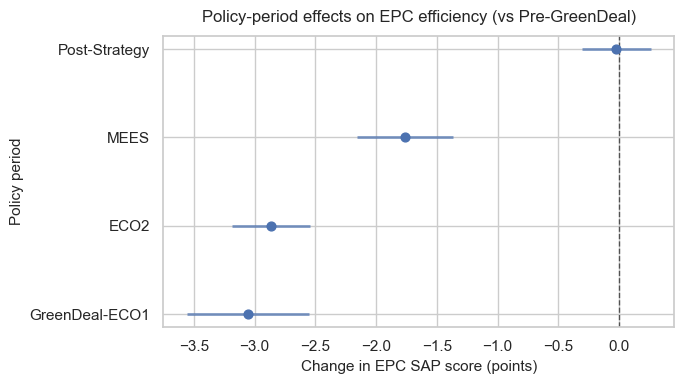

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1265593500.py:40: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


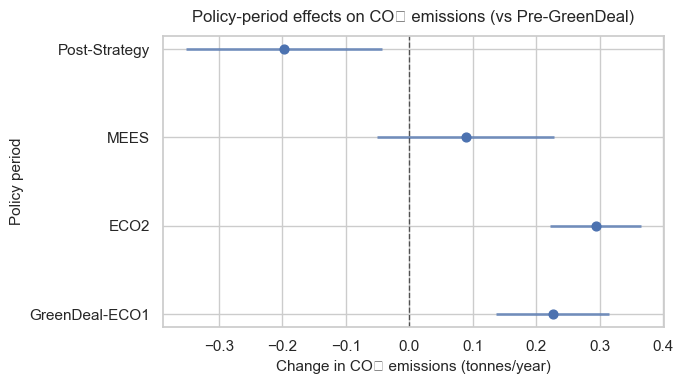

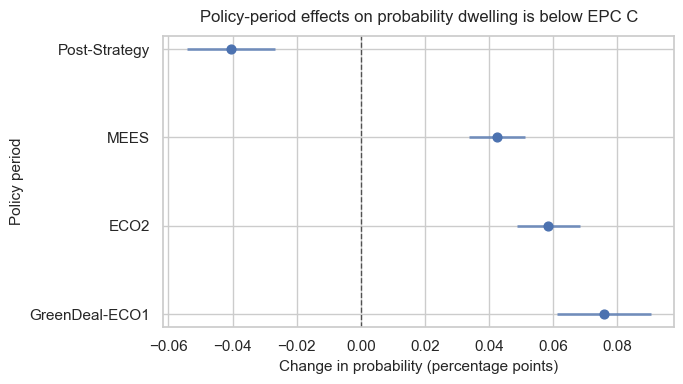

In [ ]:

# ---------------------------------------------------
# 4. Main FE models: EPC, CO2, Below C
# ---------------------------------------------------

# EPC
res_epc = fit_fe(df_panel, "CURRENT_ENERGY_EFFICIENCY")
epc_policy_effects = extract_policy_effects(res_epc)

# CO2
res_co2 = fit_fe(df_panel, "CO2_EMISSIONS_CURRENT")
co2_policy_effects = extract_policy_effects(res_co2)

# Below C
res_belowc = fit_fe(df_panel, "BELOW_C_INT")
belowc_policy_effects = extract_policy_effects(res_belowc)

# Plots
plot_policy_effects(
    epc_policy_effects,
    title="Policy-period effects on EPC efficiency (vs Pre-GreenDeal)",
    x_label="Change in EPC SAP score (points)",
)

plot_policy_effects(
    co2_policy_effects,
    title="Policy-period effects on CO₂ emissions (vs Pre-GreenDeal)",
    x_label="Change in CO₂ emissions (tonnes/year)",
)

plot_policy_effects(
    belowc_policy_effects,
    title="Policy-period effects on probability dwelling is below EPC C",
    x_label="Change in probability (percentage points)",
)



Gas subset: (1165033, 37)
Non-gas subset: (642855, 37)


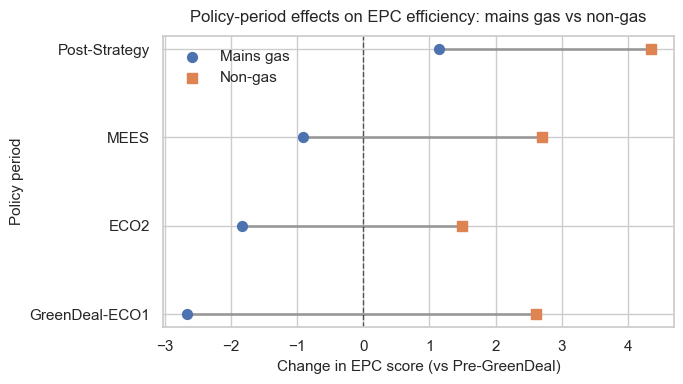

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1265593500.py:90: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


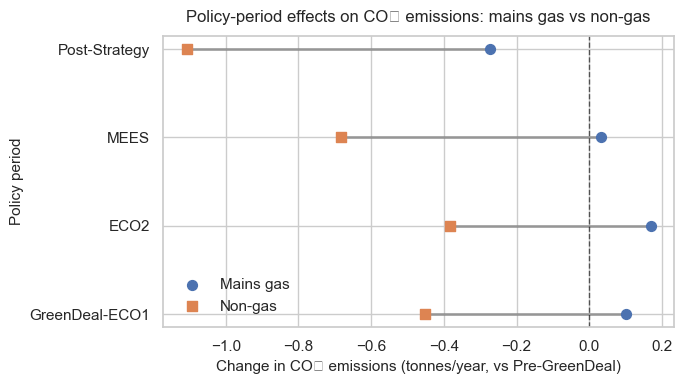

In [145]:
# ---------------------------------------------------
# 5. Heterogeneity: mains gas vs non-gas
# ---------------------------------------------------

df_gas    = df_panel[df_panel["HAS_MAINS_GAS"]].copy()
df_nongas = df_panel[~df_panel["HAS_MAINS_GAS"]].copy()

print("Gas subset:", df_gas.shape)
print("Non-gas subset:", df_nongas.shape)

# EPC
res_epc_gas    = fit_fe(df_gas, "CURRENT_ENERGY_EFFICIENCY")
res_epc_nongas = fit_fe(df_nongas, "CURRENT_ENERGY_EFFICIENCY")

epc_gas_eff    = extract_policy_effects(res_epc_gas)
epc_nongas_eff = extract_policy_effects(res_epc_nongas)

plot_dumbbell_policy(
    epc_gas_eff,
    epc_nongas_eff,
    label_a="Mains gas",
    label_b="Non-gas",
    title="Policy-period effects on EPC efficiency: mains gas vs non-gas",
    x_label="Change in EPC score (vs Pre-GreenDeal)",
)

# CO2
res_co2_gas    = fit_fe(df_gas, "CO2_EMISSIONS_CURRENT")
res_co2_nongas = fit_fe(df_nongas, "CO2_EMISSIONS_CURRENT")

co2_gas_eff    = extract_policy_effects(res_co2_gas)
co2_nongas_eff = extract_policy_effects(res_co2_nongas)

plot_dumbbell_policy(
    co2_gas_eff,
    co2_nongas_eff,
    label_a="Mains gas",
    label_b="Non-gas",
    title="Policy-period effects on CO₂ emissions: mains gas vs non-gas",
    x_label="Change in CO₂ emissions (tonnes/year, vs Pre-GreenDeal)",
)

In [146]:
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------------------------------------------------
# 1. Prep data for OLS FE models
# -------------------------------------------------------------------

# Start from your panel DF with MultiIndex (LOCAL_AUTHORITY, YEAR)
# If you're already there, just reuse df_panel
# df_panel = df_sample.set_index(["LOCAL_AUTHORITY", "YEAR"]).sort_index()

# Reset index so LOCAL_AUTHORITY is a normal column for statsmodels
df_ols = df_panel.reset_index()

# Keep only the tenure groups we care about
df_owner = df_ols[df_ols["TENURE_STD"] == "Owner-occupied"].copy()
df_prs   = df_ols[df_ols["TENURE_STD"] == "Rented (private)"].copy()

print("Owner-occupied:", df_owner.shape)
print("Private rented:", df_prs.shape)

# -------------------------------------------------------------------
# 2. Helper: OLS with LA fixed effects + clustered SEs
# -------------------------------------------------------------------

def fit_la_fe_ols(formula: str, data: pd.DataFrame):
    """
    Pooled OLS with:
      - Local authority fixed effects via C(LOCAL_AUTHORITY)
      - Cluster-robust SEs at LOCAL_AUTHORITY level
    """
    model = smf.ols(formula, data=data)
    res = model.fit(
        cov_type="cluster",
        cov_kwds={"groups": data["LOCAL_AUTHORITY"]},
    )
    return res

# -------------------------------------------------------------------
# 3. Formulas (note: TENURE not included, because we split by tenure)
# -------------------------------------------------------------------

epc_fe_formula = """
CURRENT_ENERGY_EFFICIENCY ~ 1
 + C(POLICY_PERIOD, Treatment('Pre-GreenDeal'))
 + C(PROPERTY_TYPE)
 + C(AGE_BAND_STD)
 + C(MAIN_FUEL_STD)
 + LOG_FLOOR_AREA
 + C(LOCAL_AUTHORITY)
"""

co2_fe_formula = epc_fe_formula.replace(
    "CURRENT_ENERGY_EFFICIENCY", "CO2_EMISSIONS_CURRENT"
)

# -------------------------------------------------------------------
# 4. Fit models: EPC & CO2, owners vs private-rented
# -------------------------------------------------------------------

# EPC
res_epc_owner = fit_la_fe_ols(epc_fe_formula, df_owner)
res_epc_prs   = fit_la_fe_ols(epc_fe_formula, df_prs)

print(res_epc_owner.summary())
print(res_epc_prs.summary())

# CO2
res_co2_owner = fit_la_fe_ols(co2_fe_formula, df_owner)
res_co2_prs   = fit_la_fe_ols(co2_fe_formula, df_prs)

print(res_co2_owner.summary())
print(res_co2_prs.summary())

# -------------------------------------------------------------------
# 5. Extract policy-period effects from OLS results
# -------------------------------------------------------------------

def extract_policy_effects_ols(res, label_prefix="C(POLICY_PERIOD"):
    """
    Extract policy-period coefficients from a statsmodels OLS result.

    Returns: DataFrame with
      policy_period, coef, se, lower_95, upper_95
    """
    params = res.params
    ses    = res.bse
    ci     = res.conf_int()

    rows = []
    for term, coef in params.items():
        if term.startswith(label_prefix):
            se = ses[term]
            lo, hi = ci.loc[term]
            rows.append({
                "term": term,
                "coef": coef,
                "se": se,
                "lower_95": lo,
                "upper_95": hi,
            })

    df_eff = pd.DataFrame(rows)

    # Clean term names to get the period label
    df_eff["policy_period"] = (
        df_eff["term"]
        .str.replace(r"^C\(POLICY_PERIOD, Treatment\('Pre-GreenDeal'\)\)\[T\.", "", regex=True)
        .str.replace(r"^C\(POLICY_PERIOD\)\[T\.", "", regex=True)  # fallback
        .str.replace(r"\]$", "", regex=True)
    )

    # Keep only the neat columns
    return df_eff[["policy_period", "coef", "se", "lower_95", "upper_95"]]

epc_owner_eff = extract_policy_effects_ols(res_epc_owner)
epc_prs_eff   = extract_policy_effects_ols(res_epc_prs)

co2_owner_eff = extract_policy_effects_ols(res_co2_owner)
co2_prs_eff   = extract_policy_effects_ols(res_co2_prs)

epc_owner_eff, epc_prs_eff

Owner-occupied: (972053, 39)
Private rented: (267970, 39)


/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 67, but rank is 54
  warnings.warn('covariance of constraints does not have full '
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 33, but rank is 10
  warnings.warn('covariance of constraints does not have full '


                                OLS Regression Results                               
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                       0.439
Model:                                   OLS   Adj. R-squared:                  0.439
Method:                        Least Squares   F-statistic:                 4.833e+11
Date:                       Sat, 29 Nov 2025   Prob (F-statistic):           3.45e-63
Time:                               13:50:36   Log-Likelihood:            -3.7218e+06
No. Observations:                     972053   AIC:                         7.444e+06
Df Residuals:                         971985   BIC:                         7.445e+06
Df Model:                                 67                                         
Covariance Type:                     cluster                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------

/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 67, but rank is 53
  warnings.warn('covariance of constraints does not have full '
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 33, but rank is 10
  warnings.warn('covariance of constraints does not have full '


(    policy_period      coef        se  lower_95  upper_95
 0  GreenDeal-ECO1 -3.728595  0.325705 -4.366966 -3.090225
 1            ECO2 -3.750543  0.270488 -4.280689 -3.220396
 2            MEES -1.886009  0.263884 -2.403213 -1.368806
 3   Post-Strategy  0.195785  0.172080 -0.141486  0.533055,
     policy_period          coef            se      lower_95      upper_95
 0  GreenDeal-ECO1 -5.328013e+00  3.812669e-01 -6.075282e+00 -4.580743e+00
 1            ECO2 -4.374958e+00  1.500506e-01 -4.669052e+00 -4.080865e+00
 2            MEES -2.424258e+00  2.520289e-01 -2.918225e+00 -1.930290e+00
 3   Post-Strategy -4.324307e-15  2.039437e-15 -8.321531e-15 -3.270842e-16)

In [2]:
plot_dumbbell_policy(
    epc_owner_eff,
    epc_prs_eff,
    label_a="Owner-occupied",
    label_b="Private rented",
    title="Policy-period effects on EPC efficiency: owners vs private renters",
    x_label="Change in EPC score (vs Pre-GreenDeal)",
)

plot_dumbbell_policy(
    co2_owner_eff,
    co2_prs_eff,
    label_a="Owner-occupied",
    label_b="Private rented",
    title="Policy-period effects on CO₂ emissions: owners vs private renters",
    x_label="Change in CO2 emissions (tonnes/year, vs Pre-GreenDeal)",
)

NameError: name 'plot_dumbbell_policy' is not defined

## Chapter: 5 - Predictive Modelling

In [148]:
df_panel

LMK_KEY  \
LOCAL_AUTHORITY YEAR                                                      
E06000022       2008                  177427449952008110523461208089155   
                2008                  165137860402008101521502959280418   
                2008                   39921420702008111318571957489478   
                2008                  184148980962008111015021734408178   
                2008                  191838080962008112009045424818778   
...                                                                 ...   
E06000066       2025  03c75b64de7ef53331e0457819db416e4224e6408712e6...   
                2025  03c2889c94a99e1b96e2576981e281e4bb2f96f3246634...   
                2025  03363d13db70439ef2b5e335202065817137feefc08966...   
                2025  03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...   
                2025  03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...   

                      POSTCODE         LOCAL_AUTHORITY_LABEL  \
LOCAL_AUTHORITY YEAR                                           
E06000022       2008   BA1 6JH  Bath and North East Somerset   
                2008   BA2 3PR  Bath and North East Somerset   
                2008   BA1 2QX  Bath and North East Somerset   
                2008   BA2 1AW  Bath and North East Somerset   
                2008   BA1 2QF  Bath and North East Somerset   
...                        ...                           ...   
E06000066       2025   TA6 3QW                      Somerset   
                2025  BA21 5NN                      Somerset   
                2025   TA2 7JG                      Somerset   
                2025   BA3 4HQ                      Somerset   
                2025   TA4 3JJ                      Somerset   

                                 LODGEMENT_DATE CURRENT_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                    
E06000022       2008  2008-11-05 00:00:00+00:00                     D   
                2008  2008-10-15 00:00:00+00:00                     D   
                2008  2008-11-13 00:00:00+00:00                     D   
                2008  2008-11-10 00:00:00+00:00                     D   
                2008  2008-11-20 00:00:00+00:00                     E   
...                                         ...                   ...   
E06000066       2025  2025-09-09 00:00:00+00:00                     C   
                2025  2025-09-25 00:00:00+00:00                     B   
                2025  2025-09-24 00:00:00+00:00                     C   
                2025  2025-09-25 00:00:00+00:00                     D   
                2025  2025-09-10 00:00:00+00:00                     F   

                      CURRENT_ENERGY_EFFICIENCY POTENTIAL_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                      
E06000022       2008                         58                       D   
                2008                         66                       D   
                2008                         64                       D   
                2008                         63                       C   
                2008                         47                       E   
...                                         ...                     ...   
E06000066       2025                         71                       B   
                2025                         86                       B   
                2025                         69                       C   
                2025                         55                       D   
                2025                         27                       D   

                      POTENTIAL_ENERGY_EFFICIENCY  ENERGY_CONSUMPTION_CURRENT  \
LOCAL_AUTHORITY YEAR                                                            
E06000022       2008                           62                         424   
                2008                           68                         280   
     

In [ ]:
df_mod_base = df_panel.reset_index().copy()

print(df_mod_base.shape)
df_mod_base.head()

(1807888, 39)


,LOCAL_AUTHORITY,YEAR,LMK_KEY,POSTCODE,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,...,IS_ELECTRIC_HEAT,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING,POLICY_PERIOD,LOG_FLOOR_AREA,BELOW_C_INT
0,E06000022,2008,177427449952008110523461208089155,BA1 6JH,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,...,False,True,0,0,1,0,0,Pre-GreenDeal,4.279717,1
1,E06000022,2008,165137860402008101521502959280418,BA2 3PR,Bath and North East Somerset,2008-10-15 00:00:00+00:00,D,66,D,68,...,False,True,0,0,0,0,0,Pre-GreenDeal,4.577799,1
2,E06000022,2008,39921420702008111318571957489478,BA1 2QX,Bath and North East Somerset,2008-11-13 00:00:00+00:00,D,64,D,68,...,False,True,0,0,0,0,0,Pre-GreenDeal,3.403528,1
3,E06000022,2008,184148980962008111015021734408178,BA2 1AW,Bath and North East Somerset,2008-11-10 00:00:00+00:00,D,63,C,77,...,False,True,0,0,0,0,0,Pre-GreenDeal,4.566429,1
4,E06000022,2008,191838080962008112009045424818778,BA1 2QF,Bath and North East Somerset,2008-11-20 00:00:00+00:00,E,47,E,47,...,False,True,0,0,1,0,0,Pre-GreenDeal,4.067316,1


#### Since the original data is too big to process in one go, we will take a random sample for model fitting.

In [151]:
# Target size for modelling sample
TARGET_N = 200_000

n_rows = len(df_mod_base)
sample_size = min(TARGET_N, n_rows)  # safety if dataset < 200k

df_model = df_mod_base.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print(df_model.shape)
df_model.head()

(200000, 39)


,LOCAL_AUTHORITY,YEAR,LMK_KEY,POSTCODE,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,...,IS_ELECTRIC_HEAT,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING,POLICY_PERIOD,LOG_FLOOR_AREA,BELOW_C_INT
0,E06000052,2019,1724917979702019053009044862417808,TR1 2FL,Cornwall,2019-05-30 00:00:00+00:00,B,84,A,96,...,False,False,1,1,1,0,0,MEES,4.317488,0
1,E06000023,2009,44523890102009021313491459410898,BS8 2PB,"Bristol, City of",2009-02-13 00:00:00+00:00,D,65,D,66,...,False,True,0,0,0,0,0,Pre-GreenDeal,3.918204,1
2,E06000027,2023,9287ed12eb9ef94bbed482a780c76ac60f30b905357a7f...,TQ3 2JP,Torbay,2023-08-02 00:00:00+00:00,D,62,C,74,...,False,True,0,0,0,0,0,Post-Strategy,4.653960,1
3,E06000027,2012,854780309042012110813360202320438,TQ4 6HA,Torbay,2012-11-08 00:00:00+00:00,D,65,C,79,...,False,True,0,0,0,0,0,Pre-GreenDeal,3.401197,1
4,E06000052,2022,a647aa51be1802bd18b73383c227112623912780c57fc2...,PL17 7QL,Cornwall,2022-02-27 00:00:00+00:00,E,46,B,87,...,False,True,0,0,0,0,0,Post-Strategy,4.382027,1


In [164]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   LOCAL_AUTHORITY                 200000 non-null  object  
 1   YEAR                            200000 non-null  int64   
 2   LMK_KEY                         200000 non-null  object  
 3   POSTCODE                        200000 non-null  object  
 4   LOCAL_AUTHORITY_LABEL           200000 non-null  object  
 5   LODGEMENT_DATE                  200000 non-null  object  
 6   CURRENT_ENERGY_RATING           200000 non-null  object  
 7   CURRENT_ENERGY_EFFICIENCY       200000 non-null  int64   
 8   POTENTIAL_ENERGY_RATING         200000 non-null  object  
 9   POTENTIAL_ENERGY_EFFICIENCY     200000 non-null  int64   
 10  ENERGY_CONSUMPTION_CURRENT      200000 non-null  int64   
 11  CO2_EMISSIONS_CURRENT           200000 non-null  float64 
 12  TO

In [153]:
from sklearn.model_selection import train_test_split

# Make sure BELOW_C_INT exists (0/1)
if "BELOW_C_INT" not in df_mod_base.columns:
    df_mod_base["BELOW_C_INT"] = df_mod_base["BELOW_C"].astype(int)

df_model, _ = train_test_split(
    df_mod_base,
    train_size=sample_size,
    stratify=df_mod_base["BELOW_C_INT"],
    random_state=42,
)

df_model = df_model.reset_index(drop=True)
print(df_model["BELOW_C_INT"].value_counts(normalize=True))
print(df_model.shape)

BELOW_C_INT
1    0.55906
0    0.44094
Name: proportion, dtype: float64
(200000, 39)


#### We can use df_dev to get the pipeline, preprocessing and metrics right, then rerun everything on df_model for final numbers.

In [154]:
df_dev = df_model.sample(n=30_000, random_state=123).reset_index(drop=True)
print(df_dev.shape)

(30000, 39)


In [155]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [156]:

feature_cols = [
    "PROPERTY_TYPE",
    "AGE_BAND_STD",
    "TENURE_STD",
    "MAIN_FUEL_STD",
    "LOG_FLOOR_AREA",
]

target_reg = "CURRENT_ENERGY_EFFICIENCY"
target_clf = "BELOW_C_INT"   # already created earlier

# Safety: drop rows with missing values in features or targets
df_mod = df_model.dropna(subset=feature_cols + [target_reg, target_clf]).copy()
print(df_mod.shape)

(200000, 39)


In [157]:
X = df_mod[feature_cols]
y_reg = df_mod[target_reg]
y_clf = df_mod[target_clf]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,   # keep BELOW_C balance
)

X_train.shape, X_test.shape


((160000, 5), (40000, 5))

In [158]:
# Categorical and numeric columns
cat_features = ["PROPERTY_TYPE", "AGE_BAND_STD", "TENURE_STD", "MAIN_FUEL_STD"]
num_features = ["LOG_FLOOR_AREA"]

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_features),
        ("num", numeric_transformer, num_features),
    ]
)

In [159]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [160]:
def evaluate_regression(name, model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        "model": name,
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_test":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "mae_test":   mean_absolute_error(y_test, y_pred_test),
        "r2_train":   r2_score(y_train, y_pred_train),
        "r2_test":    r2_score(y_test, y_pred_test),
    }
    return metrics

In [161]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42, max_iter=5000),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "MLPRegressor": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=200,
        random_state=42
    ),
}

In [162]:
reg_results = []

for name, base_model in reg_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", base_model),
        ]
    )
    print(f"Fitting regression model: {name}")
    pipe.fit(X_train, y_reg_train)
    
    metrics = evaluate_regression(
        name, pipe, X_train, y_reg_train, X_test, y_reg_test
    )
    reg_results.append(metrics)

reg_results_df = pd.DataFrame(reg_results).sort_values("rmse_test")
reg_results_df

Fitting regression model: LinearRegression
Fitting regression model: Ridge
Fitting regression model: Lasso
Fitting regression model: RandomForest
Fitting regression model: GradientBoosting
Fitting regression model: MLPRegressor


/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,rmse_train,rmse_test,mae_test,r2_train,r2_test
5,MLPRegressor,10.481015,10.469198,7.327459,0.520280,0.518041
4,GradientBoosting,10.793432,10.750384,7.695563,0.491254,0.491804
0,LinearRegression,10.946710,10.903106,7.916076,0.476702,0.477262
1,Ridge,10.946962,10.903476,7.916519,0.476678,0.477227
2,Lasso,10.973279,10.931383,7.948779,0.474159,0.474547
3,RandomForest,8.101605,11.346473,7.877323,0.713369,0.433884


In [163]:
from sklearn.model_selection import GridSearchCV

# Base GBR pipeline
gbr_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gbr_param_grid = {
    "model__n_estimators": [150, 250, 350],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
}

gbr_grid = GridSearchCV(
    estimator=gbr_pipe,
    param_grid=gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

print("Fitting tuned GradientBoosting...")
gbr_grid.fit(X_train, y_reg_train)

print("Best GBR params:", gbr_grid.best_params_)
best_gbr_pipe = gbr_grid.best_estimator_

# Evaluate tuned GBR using your helper
gbr_tuned_metrics = evaluate_regression(
    "GradientBoosting (tuned)", best_gbr_pipe,
    X_train, y_reg_train, X_test, y_reg_test
)
gbr_tuned_metrics

Fitting tuned GradientBoosting...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=0.8; total time=  21.5s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=0.8; total time=  21.8s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=0.8; total time=  22.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=1.0; total time=  26.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=1.0; total time=  26.4s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=150, model__subsample=1.0; total time=  26.4s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__n_estimators=250, model__subsample=0.8; total time=  35.4s
[CV] END model__learning_rate=0.03, model__max_dep

{'model': 'GradientBoosting (tuned)',
 'rmse_train': np.float64(10.441583992907287),
 'rmse_test': np.float64(10.483473321525967),
 'mae_test': 7.387995714194252,
 'r2_train': 0.5238823630635134,
 'r2_test': 0.5167256700475745}

In [171]:
best_gbr_pipe

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the preprocessor and model from the pipeline
preprocessor = best_gbr_pipe.named_steps["preprocess"]
gb_model     = best_gbr_pipe.named_steps["model"]

# 2. Get the names of the transformed features
# This works in sklearn >= 1.0 when using ColumnTransformer + OneHotEncoder
feature_names = preprocessor.get_feature_names_out()
print("Number of transformed features:", len(feature_names))

# 3. Get feature importances from the GB model
importances = gb_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi_df.head(20)

Number of transformed features: 51


,feature,importance
47,cat__TENURE_STD_Unknown,0.202989
41,cat__AGE_BAND_STD_England and Wales: before 1900,0.159912
43,cat__AGE_BAND_STD_NO DATA!,0.107653
48,cat__MAIN_FUEL_STD_gas,0.078363
49,cat__MAIN_FUEL_STD_other,0.064849
29,cat__AGE_BAND_STD_England and Wales: 1900-1929,0.050438
37,cat__AGE_BAND_STD_England and Wales: 2003-2006,0.041926
1,cat__PROPERTY_TYPE_Flat,0.039469
30,cat__AGE_BAND_STD_England and Wales: 1930-1949,0.036081
38,cat__AGE_BAND_STD_England and Wales: 2007-2011,0.035028


In [173]:
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

def aggregate_importances(fi_df):
    rows = []
    for feat, imp in zip(fi_df["feature"], fi_df["importance"]):
        if feat.startswith("cat__"):
            base = feat.split("__")[1].split("_")[0]
        elif feat.startswith("num__"):
            base = feat.split("__")[1]
        else:
            base = feat
        rows.append({"group": base, "importance": imp})
    
    agg = (
        pd.DataFrame(rows)
        .groupby("group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return agg

fi_grouped = aggregate_importances(fi_df)
print(fi_grouped)

            group  importance
0             AGE    0.546319
4          TENURE    0.211501
2            MAIN    0.143212
3        PROPERTY    0.073012
1  LOG_FLOOR_AREA    0.025956


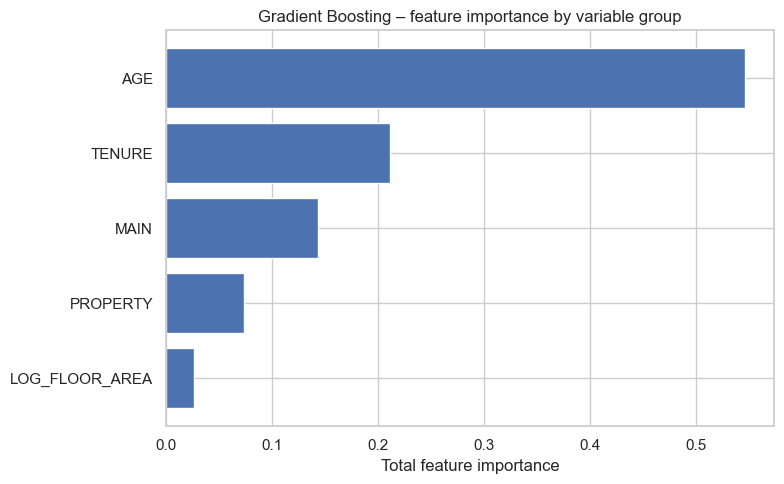

In [174]:
TOP_K = 10
plt.figure(figsize=(8,5))
top = fi_grouped.head(TOP_K).sort_values("importance")
plt.barh(top["group"], top["importance"])
plt.xlabel("Total feature importance")
plt.title("Gradient Boosting – feature importance by variable group")
plt.tight_layout()
plt.show()

In [175]:
# --- Extract transformed feature names for interpretation ---

# Get OneHotEncoder categories
ohe = preprocessor.named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(cat_features).tolist()

# Numeric features (already scaled but same name)
num_features_out = num_features

# Full transformed names
feature_names = ohe_features + num_features_out

print("Number of transformed features:", len(feature_names))

Number of transformed features: 51


In [ ]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.62.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.45.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (4.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.0/556.0 kB 12.3 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.62.1-cp311-cp311-macosx_11_0_arm64.whl (2.7 MB)
Using cached llvmlite-0.45.1-cp311-cp311-macosx_11_0_arm64.whl (37.3 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


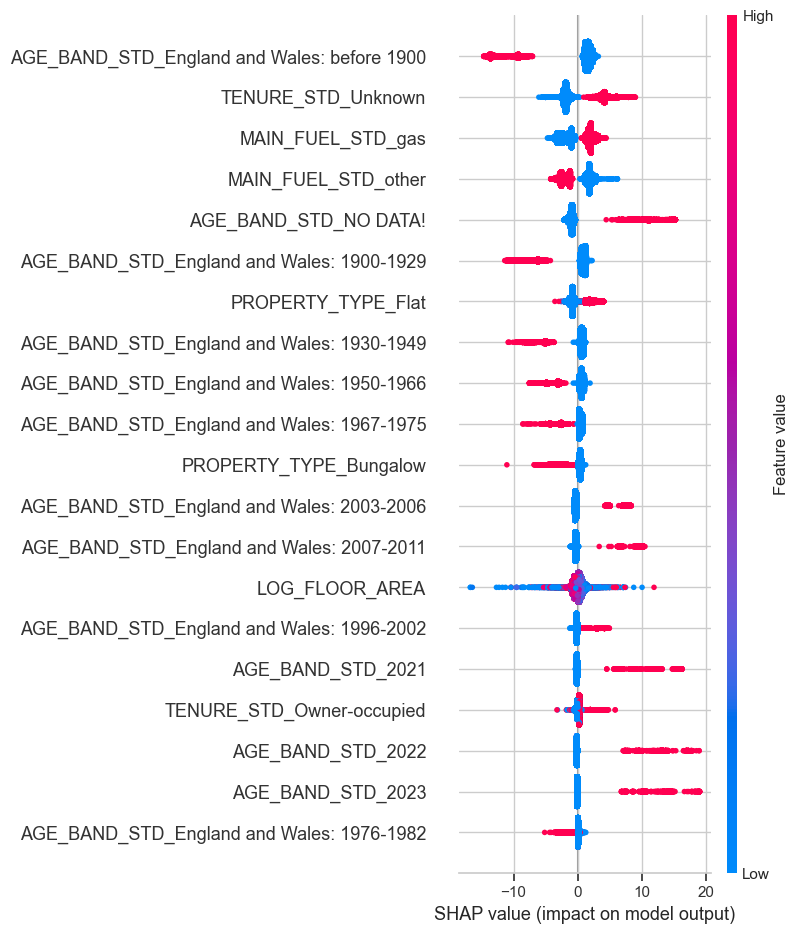

In [184]:
import shap

# Tell SHAP we use the tree explainer
model_gb = best_gbr_pipe.named_steps['model']

# Get transformed training data
X_train_trans = best_gbr_pipe.named_steps['preprocess'].transform(X_train)

explainer = shap.TreeExplainer(model_gb)
shap_values = explainer.shap_values(X_train_trans)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_trans, feature_names=feature_names)

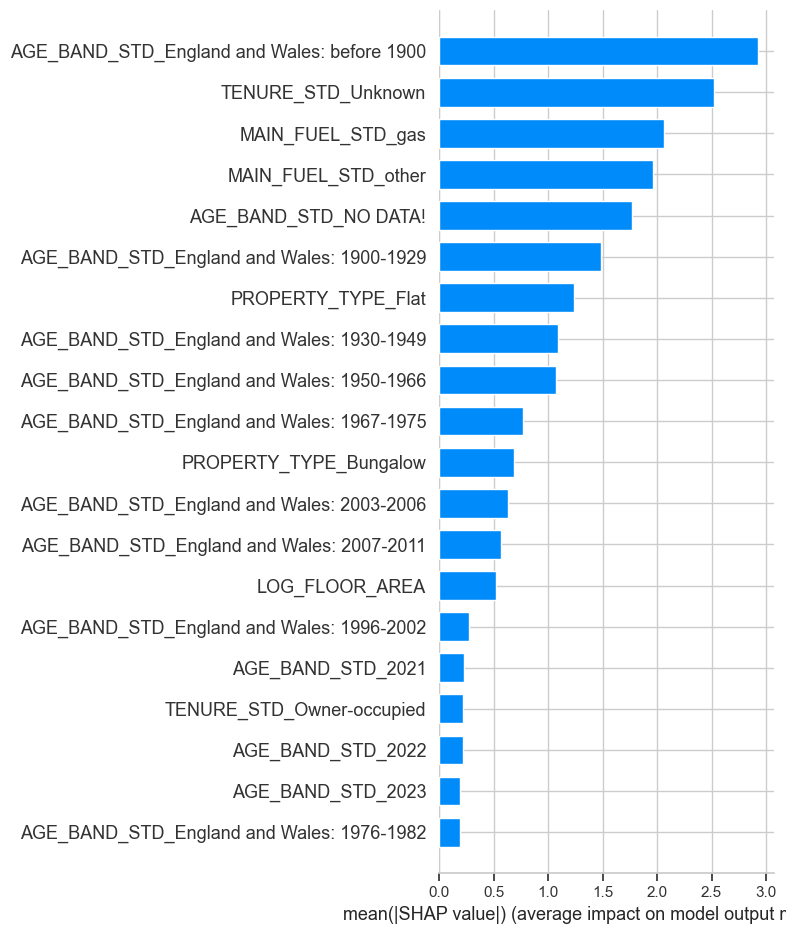

In [185]:
shap.summary_plot(
    shap_values,
    X_train_trans,
    feature_names=feature_names,
    plot_type="bar"
)

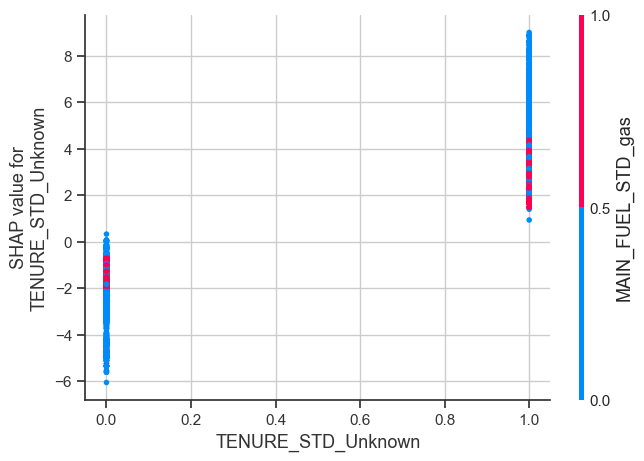

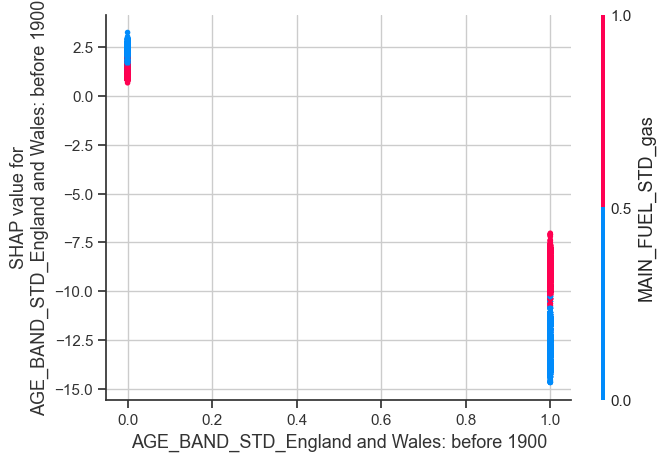

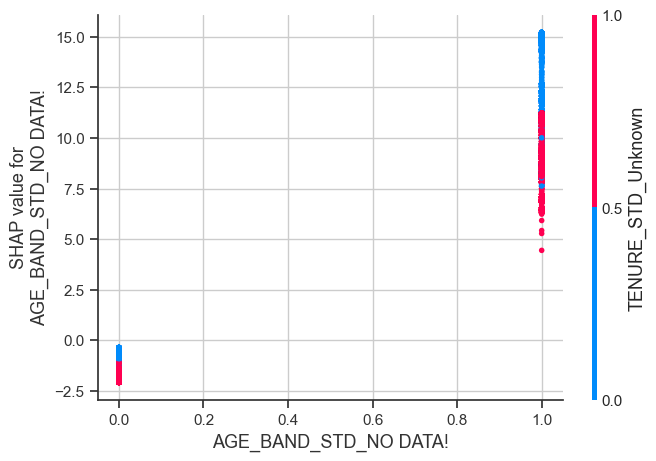

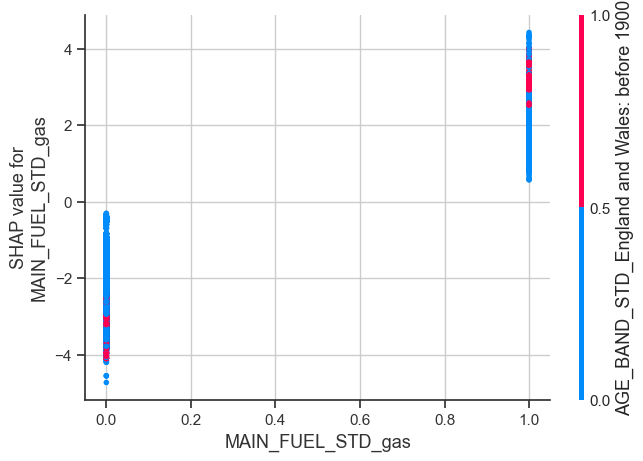

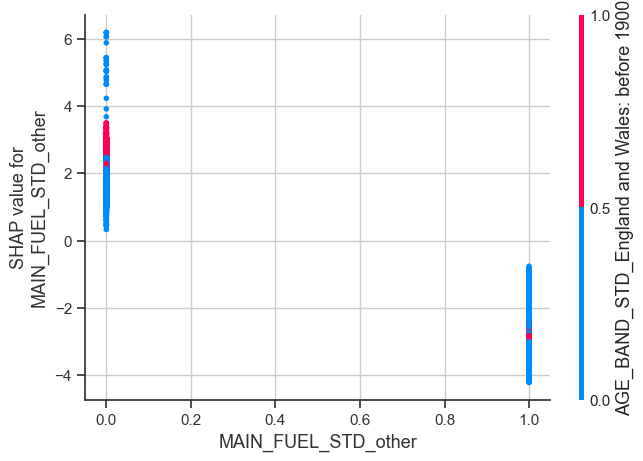

In [186]:
top5 = (
    pd.Series(model_gb.feature_importances_, index=feature_names)
      .sort_values(ascending=False)
      .head(5)
      .index
)

for feat in top5:
    shap.dependence_plot(
        feat,
        shap_values,
        X_train_trans,
        feature_names=feature_names
    )

## Classification

In [190]:
!pip install xgboost

  Using cached xgboost-3.1.2-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.2-py3-none-macosx_12_0_arm64.whl (2.2 MB)


In [192]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: evaluation function ----------

def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    """Compute core classification metrics on train and test sets."""
    # Predicted classes
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # Probabilities / scores for ROC AUC
    if hasattr(model, "predict_proba"):
        y_score_train = model.predict_proba(X_train)[:, 1]
        y_score_test  = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score_train = model.decision_function(X_train)
        y_score_test  = model.decision_function(X_test)
    else:
        # Fallback: use predicted labels (AUC will be less informative)
        y_score_train = y_pred_train
        y_score_test  = y_pred_test

    metrics = {
        "model":          name,
        "acc_train":      accuracy_score(y_train, y_pred_train),
        "acc_test":       accuracy_score(y_test, y_pred_test),
        "precision_test": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_test":    recall_score(y_test, y_pred_test, zero_division=0),
        "f1_test":        f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc_train":  roc_auc_score(y_train, y_score_train),
        "roc_auc_test":   roc_auc_score(y_test, y_score_test),
    }
    return metrics

# ---------- Define base classifiers ----------

clf_models = {
    "LogisticRegression": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

clf_results = {}
results_list = []

for name, base_model in clf_models.items():
    print(f"\nFitting classifier: {name}")
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", base_model),
        ]
    )
    pipe.fit(X_train, y_clf_train)

    metrics = evaluate_classifier(
        name, pipe, X_train, y_clf_train, X_test, y_clf_test
    )
    results_list.append(metrics)
    clf_results[name] = pipe   # store fitted pipeline

# Summary table
clf_results_df = (
    pd.DataFrame(results_list)
      .sort_values("roc_auc_test", ascending=False)
      .reset_index(drop=True)
)

clf_results_df


Fitting classifier: LogisticRegression

Fitting classifier: RandomForest

Fitting classifier: GradientBoosting

Fitting classifier: XGBoost


,model,acc_train,acc_test,precision_test,recall_test,f1_test,roc_auc_train,roc_auc_test
0,XGBoost,0.795687,0.795275,0.785297,0.872283,0.826508,0.871084,0.870947
1,GradientBoosting,0.787800,0.787950,0.777157,0.870226,0.821062,0.862023,0.863948
2,LogisticRegression,0.787763,0.788475,0.779619,0.866604,0.820814,0.861302,0.863255
3,RandomForest,0.833287,0.782500,0.781644,0.847777,0.813369,0.920843,0.852398


In [193]:
# Assuming `clf_results` dict from your loop
best_clf_name = clf_results_df.loc[0, "model"]   # should be 'XGBoost'
best_clf_pipe = clf_results[best_clf_name]

best_clf_name

'XGBoost'

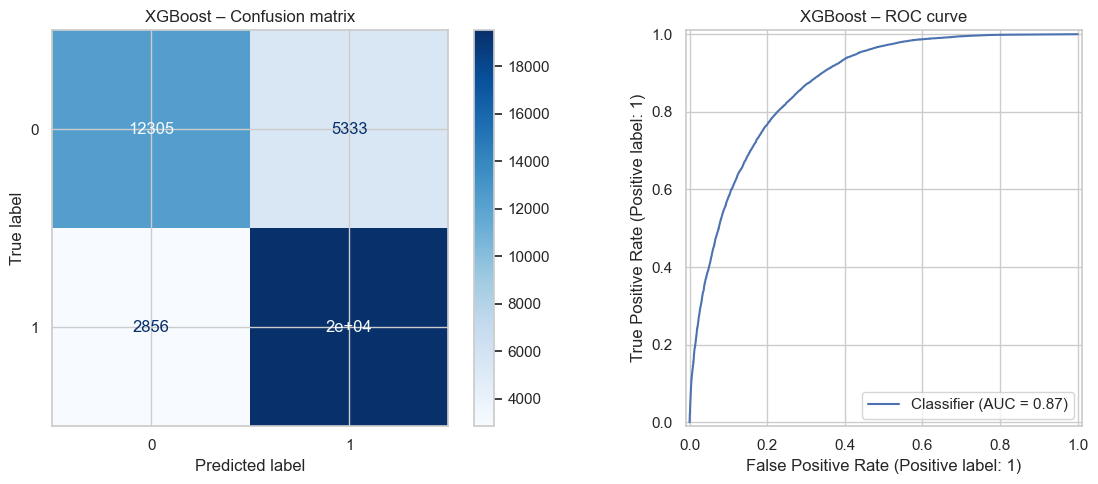

In [194]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Predictions & scores
y_pred_test = best_clf_pipe.predict(X_test)
y_score_test = best_clf_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_test, ax=axes[0], cmap="Blues"
)
axes[0].set_title(f"{best_clf_name} – Confusion matrix")

# ROC curve
RocCurveDisplay.from_predictions(
    y_clf_test, y_score_test, ax=axes[1]
)
axes[1].set_title(f"{best_clf_name} – ROC curve")

plt.tight_layout()
plt.show()

In [195]:
# 1) Get trained XGB model and the transformed feature names
xgb_clf = best_clf_pipe.named_steps["model"]

ohe = best_clf_pipe.named_steps["preprocess"].named_transformers_["cat"]
scaler = best_clf_pipe.named_steps["preprocess"].named_transformers_["num"]

cat_feature_names = list(ohe.get_feature_names_out(cat_features))
num_feature_names = num_features  # already named

feature_names_clf = cat_feature_names + num_feature_names

# 2) Get importances
importances = xgb_clf.feature_importances_

feat_imp_df = (
    pd.DataFrame({
        "feature": feature_names_clf,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

feat_imp_df.head(20)

,feature,importance
43,AGE_BAND_STD_NO DATA!,0.166201
37,AGE_BAND_STD_England and Wales: 2003-2006,0.120454
41,AGE_BAND_STD_England and Wales: before 1900,0.098418
38,AGE_BAND_STD_England and Wales: 2007-2011,0.087778
29,AGE_BAND_STD_England and Wales: 1900-1929,0.071948
47,TENURE_STD_Unknown,0.057205
30,AGE_BAND_STD_England and Wales: 1930-1949,0.047080
36,AGE_BAND_STD_England and Wales: 1996-2002,0.040886
31,AGE_BAND_STD_England and Wales: 1950-1966,0.039016
32,AGE_BAND_STD_England and Wales: 1967-1975,0.033719


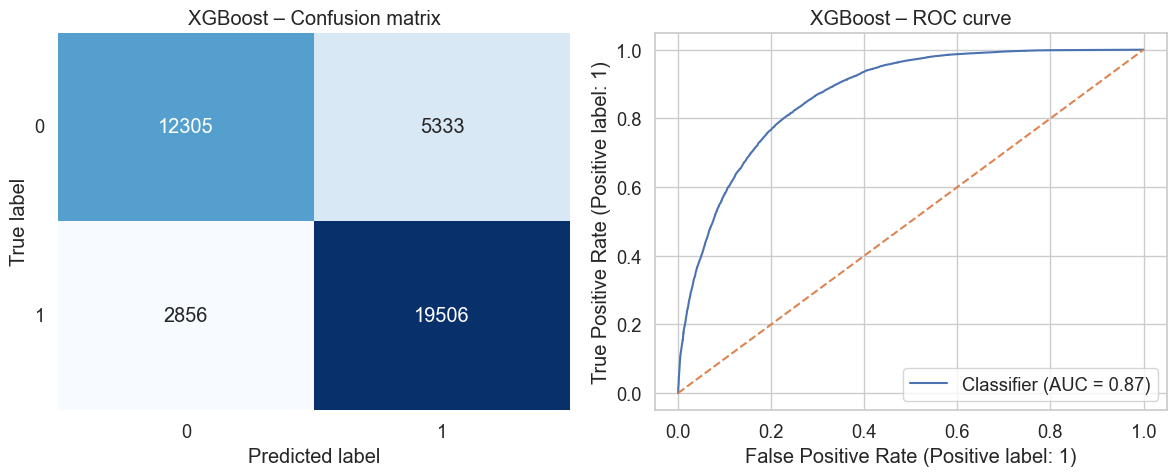

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# 1. Confusion matrix and ROC components
cm = confusion_matrix(y_clf_test, y_pred_test)
fpr, tpr, _ = roc_curve(y_clf_test, y_score_test)
roc_auc = roc_auc_score(y_clf_test, y_score_test)

# 2. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Confusion matrix ----
sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("XGBoost – Confusion matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"], rotation=0)

# ---- ROC curve ----
axes[1].plot(fpr, tpr, label=f"Classifier (AUC = {roc_auc:.2f})")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("XGBoost – ROC curve")
axes[1].set_xlabel("False Positive Rate (Positive label: 1)")
axes[1].set_ylabel("True Positive Rate (Positive label: 1)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## MLP Regressor

In [165]:
# Base MLP model
mlp_base = MLPRegressor(
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=10,
)

# Pipeline: preprocess + MLP
mlp_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", mlp_base),
    ]
)

# Hyperparameter search space
param_distributions = {
    "model__hidden_layer_sizes": [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [0.0005, 0.001, 0.01],
    "model__batch_size": [64, 128, 256],
}

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

# Randomized search over the MLP hyperparameters
mlp_search = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions=param_distributions,
    n_iter=15,                       # you can increase to 20+ if you want to be more thorough
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

print("Running RandomizedSearchCV for MLPRegressor...")
mlp_search.fit(X_train, y_reg_train)

print("\nBest params for MLPRegressor:")
print(mlp_search.best_params_)
print("\nBest CV RMSE (negative scoring transformed):")
print(-mlp_search.best_score_)

Running RandomizedSearchCV for MLPRegressor...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=   9.8s
[CV] END model__alpha=1e-05, model__batch_size=256, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=  10.0s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=  10.3s
[CV] END model__alpha=1e-05, model__batch_size=256, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=  12.1s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=  13.5s
[CV] END model__alpha=1e-05, model__batch_size=256, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=  14.2s
[CV] END model__alpha=0.01, model__batch

In [168]:
# Best tuned MLP pipeline (preprocessing + model)
mlp_best = mlp_search.best_estimator_

mlp_metrics = evaluate_regression(
    "MLPRegressor (tuned)",
    mlp_best,
    X_train,
    y_reg_train,
    X_test,
    y_reg_test,
)

mlp_metrics

{'model': 'MLPRegressor (tuned)',
 'rmse_train': np.float64(10.496691512080895),
 'rmse_test': np.float64(10.476034683703658),
 'mae_test': 7.386229989631642,
 'r2_train': 0.5188434917501032,
 'r2_test': 0.5174112495692074}

In [169]:
# Convert to DataFrame row
mlp_metrics_df = pd.DataFrame([mlp_metrics])

# Append and re-rank by test RMSE
reg_results_df = pd.concat([reg_results_df, mlp_metrics_df], ignore_index=True)
reg_results_df = reg_results_df.sort_values("rmse_test").reset_index(drop=True)

reg_results_df

,model,rmse_train,rmse_test,mae_test,r2_train,r2_test
0,MLPRegressor,10.481015,10.469198,7.327459,0.520280,0.518041
1,MLPRegressor (tuned),10.496692,10.476035,7.386230,0.518843,0.517411
2,GradientBoosting,10.793432,10.750384,7.695563,0.491254,0.491804
3,LinearRegression,10.946710,10.903106,7.916076,0.476702,0.477262
4,Ridge,10.946962,10.903476,7.916519,0.476678,0.477227
5,Lasso,10.973279,10.931383,7.948779,0.474159,0.474547
6,RandomForest,8.101605,11.346473,7.877323,0.713369,0.433884


## Below's work is the test work and consist of mostly redundant code

In [90]:
# Ensure POLICY_PERIOD is a categorical with a clear order
policy_order = [
    "Pre-GreenDeal",
    "GreenDeal-ECO1",
    "ECO2",
    "MEES",
    "Post-Strategy"
]

df_sample["POLICY_PERIOD"] = pd.Categorical(
    df_sample["POLICY_PERIOD"],
    categories=policy_order,
    ordered=True
)


# Set panel index: entity = LOCAL_AUTHORITY, time = YEAR
df_panel = df_sample.set_index(["LOCAL_AUTHORITY", "YEAR"])

In [91]:
df_panel.head()

LMK_KEY  POSTCODE  \
LOCAL_AUTHORITY YEAR                                                
E06000058       2008   29087020002008100209344654182258   BH1 3QF   
E06000030       2008  162691330702008101308085753289378   SN5 5RZ   
E06000022       2008  177427449952008110523461208089155   BA1 6JH   
E06000052       2008   37743650742008111311541854389578  PL14 4NP   
                2008  158859350832008101718063789968495  PL26 8EY   

                                    LOCAL_AUTHORITY_LABEL  \
LOCAL_AUTHORITY YEAR                                        
E06000058       2008  Bournemouth, Christchurch and Poole   
E06000030       2008                              Swindon   
E06000022       2008         Bath and North East Somerset   
E06000052       2008                             Cornwall   
                2008                             Cornwall   

                                 LODGEMENT_DATE CURRENT_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                    
E06000058       2008  2008-10-02 00:00:00+00:00                     B   
E06000030       2008  2008-10-13 00:00:00+00:00                     C   
E06000022       2008  2008-11-05 00:00:00+00:00                     D   
E06000052       2008  2008-11-13 00:00:00+00:00                     E   
                2008  2008-10-17 00:00:00+00:00                     D   

                      CURRENT_ENERGY_EFFICIENCY POTENTIAL_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                      
E06000058       2008                         84                       B   
E06000030       2008                         69                       C   
E06000022       2008                         58                       D   
E06000052       2008                         44                       E   
                2008                         57                       D   

                      POTENTIAL_ENERGY_EFFICIENCY  ENERGY_CONSUMPTION_CURRENT  \
LOCAL_AUTHORITY YEAR                                                            
E06000058       2008                           85                         132   
E06000030       2008                           76                         275   
E06000022       2008                           62                         424   
E06000052       2008                           52                         549   
                2008                           59                         471   

                      CO2_EMISSIONS_CURRENT  ...  HAS_MAINS_GAS  \
LOCAL_AUTHORITY YEAR                         ...                  
E06000058       2008                    1.4  ...          False   
E06000030       2008                    2.8  ...           True   
E06000022       2008                    4.6  ...          False   
E06000052       2008                    4.6  ...          False   
                2008                    6.2  ...          False   

                     IS_ELECTRIC_HEAT BELOW_C NUMBER_HABITABLE_ROOMS_MISSING  \
LOCAL_AUTHORITY YEAR                                                           
E06000058       2008            False   False                              1   
E06000030       2008            False   False                              0   
E06000022       2008            False    True                              0   
E06000052       2008            False    True                              0   
                2008            False    True                              0   

                     NUMBER_HEATED_ROOMS_MISSING MAINS_GAS_FLAG_MISSING  \
LOCAL_AUTHORITY YEAR                                                      
E06000058       2008                           1                      1   
E06000030       2008                           0                      0   
E06000022       2008                           0                      1   
E06000052       2008                           0                      0   
                2008                           0 

In [ ]:
# EPC fixed-effects model: LA FE + policy periods + controls
mod_epc = PanelOLS.from_formula(
    """
    CURRENT_ENERGY_EFFICIENCY
    ~ 1
      + C(POLICY_PERIOD)
      + C(PROPERTY_TYPE)
      + C(AGE_BAND_STD)
      + C(TENURE_STD)
      + C(MAIN_FUEL_STD)
      + LOG_FLOOR_AREA
      + EntityEffects
    """,
    data=df_panel
)

res_epc = mod_epc.fit(cov_type="robust")  # heteroskedasticity-robust SEs
print(res_epc.summary)

                              PanelOLS Estimation Summary                              
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                        0.4741
Estimator:                          PanelOLS   R-squared (Between):              0.7774
No. Observations:                    1807888   R-squared (Within):               0.4741
Date:                       Sat, Nov 29 2025   R-squared (Overall):              0.4815
Time:                               12:26:19   Log-likelihood                -6.867e+06
Cov. Estimator:                       Robust                                           
                                               F-statistic:                   2.264e+04
Entities:                                 12   P-value                           0.0000
Avg Obs:                           1.507e+05   Distribution:              F(72,1807804)
Min Obs:                           3.763e+04                                           
Max Obs:                        

In [94]:
df_panel["BELOW_C_INT"] = df_panel["BELOW_C"].astype(int)

In [ ]:
mod_belowc = PanelOLS.from_formula(
    """
    BELOW_C_INT
    ~ 1
      + C(POLICY_PERIOD)
      + C(PROPERTY_TYPE)
      + C(AGE_BAND_STD)
      + C(TENURE_STD)
      + C(MAIN_FUEL_STD)
      + LOG_FLOOR_AREA
      + EntityEffects
    """,
    data=df_panel
)

res_belowc = mod_belowc.fit(cov_type="robust")
print(res_belowc.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            BELOW_C_INT   R-squared:                        0.3909
Estimator:                   PanelOLS   R-squared (Between):              0.8881
No. Observations:             1807888   R-squared (Within):               0.3909
Date:                Sat, Nov 29 2025   R-squared (Overall):              0.3959
Time:                        12:27:01   Log-likelihood                 -8.42e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.611e+04
Entities:                          12   P-value                           0.0000
Avg Obs:                    1.507e+05   Distribution:              F(72,1807804)
Min Obs:                    3.763e+04                                           
Max Obs:                    3.032e+05   F-statistic (robust):         -2.329e+15
                            

In [96]:
def extract_policy_effects(res, prefix="C(POLICY_PERIOD)"):
    params = res.params.filter(like=prefix)
    se = res.std_errors.filter(like=prefix)

    out = (
        pd.concat([params, se], axis=1)
          .reset_index()
    )
    out.columns = ["term", "coef", "se"]
    out["lower_95"] = out["coef"] - 1.96 * out["se"]
    out["upper_95"] = out["coef"] + 1.96 * out["se"]
    return out

co2_policy_effects = extract_policy_effects(res_co2)
belowc_policy_effects = extract_policy_effects(res_belowc)

co2_policy_effects, belowc_policy_effects

(                                 term      coef        se  lower_95  upper_95
 0  C(POLICY_PERIOD)[T.GreenDeal-ECO1]  0.225815  0.004730  0.216543  0.235086
 1            C(POLICY_PERIOD)[T.ECO2]  0.293155  0.005184  0.282993  0.303317
 2            C(POLICY_PERIOD)[T.MEES]  0.088931  0.004944  0.079241  0.098620
 3   C(POLICY_PERIOD)[T.Post-Strategy] -0.197279  0.004543 -0.206182 -0.188376,
                                  term      coef        se  lower_95  upper_95
 0  C(POLICY_PERIOD)[T.GreenDeal-ECO1]  0.075883  0.000891  0.074138  0.077629
 1            C(POLICY_PERIOD)[T.ECO2]  0.058433  0.000954  0.056563  0.060304
 2            C(POLICY_PERIOD)[T.MEES]  0.042470  0.001050  0.040411  0.044528
 3   C(POLICY_PERIOD)[T.Post-Strategy] -0.040475  0.000954 -0.042345 -0.038604)

In [97]:
# Subsample: dwellings on the gas grid
df_gas = df_panel[df_panel["HAS_MAINS_GAS"] == True].copy()

print(df_gas.shape)  # just to check size

mod_epc_gas = PanelOLS.from_formula(
    """
    CURRENT_ENERGY_EFFICIENCY
    ~ 1
      + C(POLICY_PERIOD)
      + C(PROPERTY_TYPE)
      + C(AGE_BAND_STD)
      + C(TENURE_STD)
      + C(MAIN_FUEL_STD)
      + LOG_FLOOR_AREA
      + EntityEffects
    """,
    data=df_gas
)

res_epc_gas = mod_epc_gas.fit(cov_type="robust")
print(res_epc_gas.summary)

(1165033, 37)
                              PanelOLS Estimation Summary                              
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                        0.3515
Estimator:                          PanelOLS   R-squared (Between):              0.9003
No. Observations:                    1165033   R-squared (Within):               0.3515
Date:                       Sat, Nov 29 2025   R-squared (Overall):              0.3563
Time:                               12:27:06   Log-likelihood                -4.219e+06
Cov. Estimator:                       Robust                                           
                                               F-statistic:                   2.429e+04
Entities:                                 12   P-value                           0.0000
Avg Obs:                           9.709e+04   Distribution:              F(26,1164995)
Min Obs:                           2.174e+04                                           
Max Obs:          

In [98]:
import pandas as pd

def extract_policy_effects(res, label_prefix="C(POLICY_PERIOD)"):
    """
    Extract policy-period coefficients from a PanelOLS result.

    Returns a tidy DataFrame with:
    term, coef, se, lower_95, upper_95
    """
    params = res.params
    ses = res.std_errors
    ci = res.conf_int()

    rows = []
    for term, coef in params.items():
        if term.startswith(label_prefix):
            se = ses[term]
            lo, hi = ci.loc[term]
            rows.append({
                "term": term,
                "coef": coef,
                "se": se,
                "lower_95": lo,
                "upper_95": hi,
            })

    df_eff = pd.DataFrame(rows).sort_values("coef").reset_index(drop=True)

    # Clean up to just the policy-period name
    df_eff["policy_period"] = (
        df_eff["term"]
        .str.replace(r"^C\(POLICY_PERIOD\)\[T\.", "", regex=True)
        .str.replace(r"\]$", "", regex=True)
    )

    return df_eff[["policy_period", "coef", "se", "lower_95", "upper_95"]]

In [99]:
epc_policy_effects    = extract_policy_effects(res_epc)
co2_policy_effects    = extract_policy_effects(res_co2)
belowc_policy_effects = extract_policy_effects(res_belowc)

epc_policy_effects

,policy_period,coef,se,lower_95,upper_95
0,GreenDeal-ECO1,-3.055822,0.027860,-3.110426,-3.001218
1,ECO2,-2.861249,0.029547,-2.919159,-2.803338
2,MEES,-1.759984,0.029953,-1.818690,-1.701277
3,Post-Strategy,-0.021019,0.027040,-0.074017,0.031978


In [100]:
co2_policy_effects

,policy_period,coef,se,lower_95,upper_95
0,Post-Strategy,-0.197279,0.004543,-0.206182,-0.188376
1,MEES,0.088931,0.004944,0.079241,0.098620
2,GreenDeal-ECO1,0.225815,0.004730,0.216544,0.235086
3,ECO2,0.293155,0.005184,0.282994,0.303316


In [101]:
belowc_policy_effects

,policy_period,coef,se,lower_95,upper_95
0,Post-Strategy,-0.040475,0.000954,-0.042345,-0.038604
1,MEES,0.042470,0.001050,0.040411,0.044528
2,ECO2,0.058433,0.000954,0.056563,0.060304
3,GreenDeal-ECO1,0.075883,0.000891,0.074138,0.077629


epc_policy_effects.to_csv("outputs/epc_policy_effects.csv", index=False)
co2_policy_effects.to_csv("outputs/co2_policy_effects.csv", index=False)
belowc_policy_effects.to_csv("outputs/belowc_policy_effects.csv", index=False)

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

def plot_policy_effects(df_eff, title, x_label, zero_line=True):
    """
    Plot policy-period coefficients with 95% CI.

    df_eff should have columns:
        policy_period, coef, lower_95, upper_95
    """
    # Order periods in sensible chronological order if present:
    order = ["Pre-GreenDeal", "GreenDeal-ECO1", "ECO2", "MEES", "Post-Strategy"]
    df_plot = df_eff.copy()
    df_plot["policy_period"] = pd.Categorical(
        df_plot["policy_period"], categories=order, ordered=True
    )
    df_plot = df_plot.sort_values("policy_period")

    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Plot CI as horizontal lines
    ax.hlines(
        y=df_plot["policy_period"],
        xmin=df_plot["lower_95"],
        xmax=df_plot["upper_95"],
        linewidth=2,
        alpha=0.7,
    )

    # Plot point estimates
    ax.scatter(
        df_plot["coef"],
        df_plot["policy_period"],
        s=40,
        zorder=3,
    )

    if zero_line:
        ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Policy period", fontsize=11)

    plt.tight_layout()
    plt.show()

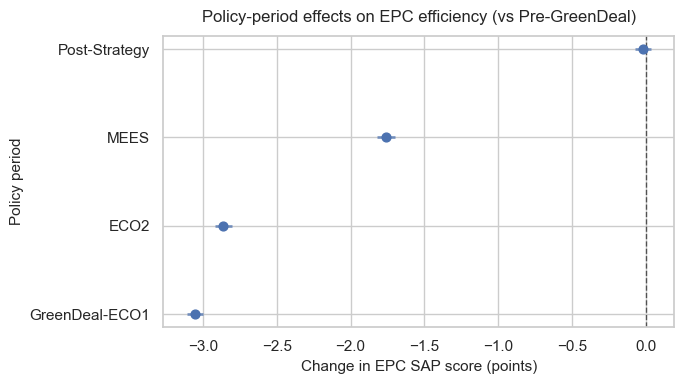

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_45462/1206867176.py:48: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


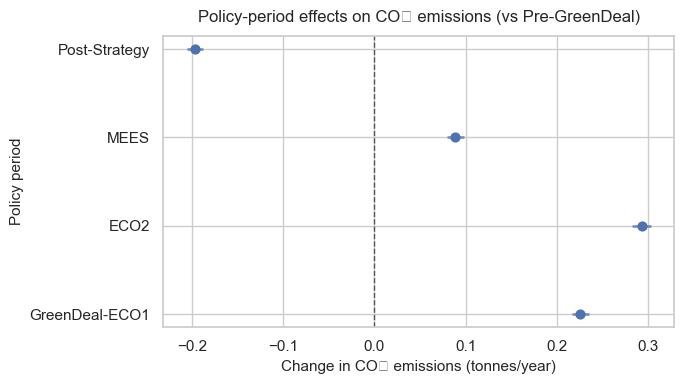

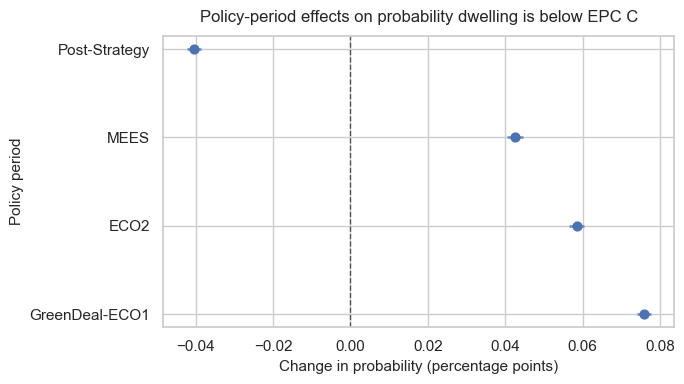

In [ ]:
plot_policy_effects(
    epc_policy_effects,
    title="Policy-period effects on EPC efficiency (vs Pre-GreenDeal)",
    x_label="Change in EPC SAP score (points)",
)

plot_policy_effects(
    co2_policy_effects,
    title="Policy-period effects on CO₂ emissions (vs Pre-GreenDeal)",
    x_label="Change in CO₂ emissions (tonnes/year)",
)

plot_policy_effects(
    belowc_policy_effects,
    title="Policy-period effects on probability dwelling is below EPC C",
    x_label="Change in probability (percentage points)",
)

In [109]:
epc_formula = """
CURRENT_ENERGY_EFFICIENCY ~ 1
 + C(POLICY_PERIOD)
 + C(PROPERTY_TYPE)
 + C(AGE_BAND_STD)
 + C(TENURE_STD)
 + C(MAIN_FUEL_STD)
 + LOG_FLOOR_AREA
 + EntityEffects
"""

In [110]:
# Gas subset
mask_gas    = df_panel["HAS_MAINS_GAS"] == True
mask_nongas = df_panel["HAS_MAINS_GAS"] == False

df_gas    = df_panel[mask_gas]
df_nongas = df_panel[mask_nongas]

print(df_gas.shape, df_nongas.shape)

(1165033, 37) (642855, 37)


In [107]:
from linearmodels.panel import PanelOLS

In [ ]:
df_panel

LMK_KEY  \
LOCAL_AUTHORITY YEAR                                                      
E06000058       2008                   29087020002008100209344654182258   
E06000030       2008                  162691330702008101308085753289378   
E06000022       2008                  177427449952008110523461208089155   
E06000052       2008                   37743650742008111311541854389578   
                2008                  158859350832008101718063789968495   
...                                                                 ...   
                2025  03c5078838a4bccc40c0f49c4c625b90643adc2c6782f3...   
E06000066       2025  03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...   
                2025  03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...   
E06000027       2025  03f62c5b45b13282b4b2647422f2e927a88bdf3d5ae7c6...   
E06000052       2025  03c16cd03f1486bbc7aba35916c10196952fdb27d5f01f...   

                      POSTCODE                LOCAL_AUTHORITY_LABEL  \
LOCAL_AUTHORITY YEAR                                                  
E06000058       2008   BH1 3QF  Bournemouth, Christchurch and Poole   
E06000030       2008   SN5 5RZ                              Swindon   
E06000022       2008   BA1 6JH         Bath and North East Somerset   
E06000052       2008  PL14 4NP                             Cornwall   
                2008  PL26 8EY                             Cornwall   
...                        ...                                  ...   
                2025  PL18 9FX                             Cornwall   
E06000066       2025   BA3 4HQ                             Somerset   
                2025   TA4 3JJ                             Somerset   
E06000027       2025   TQ1 4AL                               Torbay   
E06000052       2025  PL13 1PG                             Cornwall   

                                 LODGEMENT_DATE CURRENT_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                    
E06000058       2008  2008-10-02 00:00:00+00:00                     B   
E06000030       2008  2008-10-13 00:00:00+00:00                     C   
E06000022       2008  2008-11-05 00:00:00+00:00                     D   
E06000052       2008  2008-11-13 00:00:00+00:00                     E   
                2008  2008-10-17 00:00:00+00:00                     D   
...                                         ...                   ...   
                2025  2025-09-27 00:00:00+00:00                     B   
E06000066       2025  2025-09-25 00:00:00+00:00                     D   
                2025  2025-09-10 00:00:00+00:00                     F   
E06000027       2025  2025-09-09 00:00:00+00:00                     C   
E06000052       2025  2025-09-11 00:00:00+00:00                     D   

                      CURRENT_ENERGY_EFFICIENCY POTENTIAL_ENERGY_RATING  \
LOCAL_AUTHORITY YEAR                                                      
E06000058       2008                         84                       B   
E06000030       2008                         69                       C   
E06000022       2008                         58                       D   
E06000052       2008                         44                       E   
                2008                         57                       D   
...                                         ...                     ...   
                2025                         81                       B   
E06000066       2025                         55                       D   
                2025                         27                       D   
E06000027       2025                         71                       C   
E06000052       2025                         67                       B   

                      POTENTIAL_ENERGY_EFFICIENCY  ENERGY_CONSUMPTION_CURRENT  \
LOCAL_AUTHORITY YEAR                                                            
E06000058       2008                           85                         13

In [118]:
import pandas as pd
from linearmodels.panel import PanelOLS

def fit_panel_with_clusters(formula: str, data: pd.DataFrame):
    """
    Fit PanelOLS with LA fixed effects (via EntityEffects in formula)
    and cluster-robust SEs at local-authority level.
    """
    # clusters must be array-like with same index as data
    clusters = pd.Series(
        data.index.get_level_values("LOCAL_AUTHORITY"),
        index=data.index,
        name="cluster_la",
    )

    mod = PanelOLS.from_formula(
        formula,
        data=data,
    )
    res = mod.fit(
        cov_type="clustered",
        clusters=clusters,
    )
    return res

In [119]:
# Make sure df_panel is already set:
# df_panel = df.set_index(["LOCAL_AUTHORITY", "YEAR"]).sort_index()

# Subsets
df_gas = df_panel[df_panel["HAS_MAINS_GAS"]].copy()
df_nongas = df_panel[~df_panel["HAS_MAINS_GAS"]].copy()

print(df_gas.shape, df_nongas.shape)

# Common formula with LA fixed effects
epc_formula = """
CURRENT_ENERGY_EFFICIENCY ~ 1
 + C(POLICY_PERIOD)
 + C(PROPERTY_TYPE)
 + C(AGE_BAND_STD)
 + C(TENURE_STD)
 + C(MAIN_FUEL_STD)
 + LOG_FLOOR_AREA
 + EntityEffects
"""

co2_formula = epc_formula.replace(
    "CURRENT_ENERGY_EFFICIENCY", "CO2_EMISSIONS_CURRENT"
)

# EPC: gas / non-gas
res_epc_gas    = fit_panel_with_clusters(epc_formula, df_gas)
res_epc_nongas = fit_panel_with_clusters(epc_formula, df_nongas)

print(res_epc_gas.summary)
print(res_epc_nongas.summary)

# CO2: gas / non-gas
res_co2_gas    = fit_panel_with_clusters(co2_formula, df_gas)
res_co2_nongas = fit_panel_with_clusters(co2_formula, df_nongas)

print(res_co2_gas.summary)
print(res_co2_nongas.summary)

(1165033, 37) (642855, 37)
                              PanelOLS Estimation Summary                              
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                        0.3515
Estimator:                          PanelOLS   R-squared (Between):              0.9003
No. Observations:                    1165033   R-squared (Within):               0.3515
Date:                       Sat, Nov 29 2025   R-squared (Overall):              0.3563
Time:                               12:42:07   Log-likelihood                -4.219e+06
Cov. Estimator:                    Clustered                                           
                                               F-statistic:                   2.429e+04
Entities:                                 12   P-value                           0.0000
Avg Obs:                           9.709e+04   Distribution:              F(26,1164995)
Min Obs:                           2.174e+04                                           
Max O

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

def plot_dumbbell_policy(
    df_a,
    df_b,
    label_a,
    label_b,
    title,
    x_label,
    zero_line=True
):
    """
    Dumbbell plot comparing policy-period effects from two models.
    
    df_a, df_b: DataFrames from extract_policy_effects()
                with columns ['policy_period','coef', 'lower_95', 'upper_95']
    label_a, label_b: legend labels for the two groups (e.g. 'Mains gas', 'Non-gas')
    """

    # Merge on policy_period
    df = df_a.merge(df_b, on="policy_period", suffixes=("_a", "_b"))

    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Horizontal line between the two coefficients (the 'dumbbell' stick)
    ax.hlines(
        y=df["policy_period"],
        xmin=df["coef_a"],
        xmax=df["coef_b"],
        color="grey",
        alpha=0.7,
        linewidth=2,
    )

    # End points (the 'bells')
    ax.scatter(df["coef_a"], df["policy_period"],
               s=50, label=label_a, zorder=3)
    ax.scatter(df["coef_b"], df["policy_period"],
               s=50, marker="s", label=label_b, zorder=3)

    # Optional vertical zero line
    if zero_line:
        ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Policy period", fontsize=11)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

In [1]:
# --- EPC: gas vs non-gas ---
epc_gas_eff    = extract_policy_effects(res_epc_gas)
epc_nongas_eff = extract_policy_effects(res_epc_nongas)

plot_dumbbell_policy(
    epc_gas_eff,
    epc_nongas_eff,
    label_a="Mains gas",
    label_b="Non-gas",
    title="Policy-period effects on EPC efficiency: mains gas vs non-gas",
    x_label="Change in EPC score (vs Pre-GreenDeal)"
)

# --- CO2: gas vs non-gas ---
co2_gas_eff    = extract_policy_effects(res_co2_gas)
co2_nongas_eff = extract_policy_effects(res_co2_nongas)

plot_dumbbell_policy(
    co2_gas_eff,
    co2_nongas_eff,
    label_a="Mains gas",
    label_b="Non-gas",
    title="Policy-period effects on CO2 emissions: mains gas vs non-gas",
    x_label="Change in CO2 emissions (tonnes/year, vs Pre-GreenDeal)"
)

NameError: name 'extract_policy_effects' is not defined

✔ 1. PanelOLS (Fixed Effects regression) — your main causal model

Controls for unobserved LA-level differences.

✔ 2. OLS + Clustered SE — for heterogeneity analysis

Stable for subgroups with fewer observations.


In [136]:
import statsmodels.formula.api as smf

def run_ols_clustered(df, formula):
    """
    Runs OLS with standard errors clustered by LOCAL_AUTHORITY.
    """
    model = smf.ols(formula=formula, data=df).fit(
        cov_type="cluster",
        cov_kwds={"groups": df["LOCAL_AUTHORITY"]}
    )
    return model